# Proyecto Precálculo — EDA comprehensivo y auditoría de fuga

## Propósito y alcance

Este notebook documenta el análisis exploratorio de la base de precálculo antes de construir
cualquier modelo de regresión. El conjunto de prueba ya está separado en un CSV independiente y
se conserva reservado: las decisiones descriptivas, las imputaciones auxiliares, las pruebas
estadísticas, las transformaciones exploratorias, la reducción de dimensionalidad y la detección
de outliers se calculan únicamente con el conjunto de entrenamiento.

La variable objetivo es nota_primer_parcial. La columna nota_final se conserva en la lectura para
auditarla, pero se excluye de las variables predictoras por ser un resultado posterior y por su
potencial relación directa con el objetivo. Este notebook no entrena modelos de regresión; su
salida es un diagnóstico documentado para el notebook posterior de modelado.

## Orden metodológico

1. Carga separada, control de esquema y verificación del conjunto reservado.
2. Perfil de calidad y definición de roles de variables.
3. EDA univariado del objetivo, variables numéricas y variables categóricas.
4. EDA bivariado: asociaciones numéricas, comparaciones por grupos y tablas de contingencia.
5. Correlación, multicolinealidad y asociaciones no lineales.
6. EDA multivariado: PCA, outliers multivariados y clustering exploratorio.
7. Auditoría de disponibilidad temporal, proxies, identificadores, duplicados y rendimiento
   univariado como señal de alerta de fuga.
8. Síntesis de decisiones para el notebook de regresión.

Las pruebas de significancia se acompañan de tamaños de efecto y corrección FDR de
Benjamini-Hochberg. Con muestras grandes, un valor p pequeño no se interpreta como evidencia
suficiente de relevancia práctica.

## 0. Configuración, funciones auxiliares y criterios reproducibles

Se definen aquí los criterios que gobiernan todo el análisis. La categoría rara se marca con una
frecuencia inferior al 1 %; no se recodifica automáticamente en este notebook. Los outliers
univariados se identifican mediante el criterio IQR; para este ejercicio no se eliminan porque representan comportamiento real de la población. Las pruebas de normalidad se
calculan sobre una muestra acotada y se interpretan con cautela, porque con n grande detectan
desviaciones pequeñas.

In [1]:
import math
import re
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor, IsolationForest
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 90)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
TARGET = 'nota_primer_parcial'
EXCLUDED_FROM_MODEL = ['nota_final']
RARE_CATEGORY_THRESHOLD = 0.01
NORMALITY_SAMPLE_SIZE = 5000
LEAKAGE_R2_ALERT = 0.80
CORRELATION_ALERT = 0.80


def locate_data_file(filename):
    candidates = [Path(filename), Path('Precalculo') / filename]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'No se encontró {filename}. Rutas revisadas: {candidates}')


def make_dense_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def fdr_bh(pvalues):
    values = np.asarray(pvalues, dtype=float)
    result = np.full(values.shape, np.nan, dtype=float)
    valid = np.isfinite(values)
    if valid.sum() == 0:
        return result
    pv = values[valid]
    order = np.argsort(pv)
    ranked = pv[order]
    adjusted = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    inverse = np.empty_like(order)
    inverse[order] = np.arange(len(order))
    result[valid] = adjusted[inverse]
    return result


def cramers_v(table):
    observed = np.asarray(table, dtype=float)
    if observed.size == 0 or observed.sum() == 0:
        return np.nan
    chi2 = stats.chi2_contingency(observed, correction=False)[0]
    n = observed.sum()
    if n <= 1:
        return np.nan
    phi2 = chi2 / n
    rows, cols = observed.shape
    phi2corr = max(0, phi2 - ((cols - 1) * (rows - 1)) / (n - 1))
    rcorr = rows - ((rows - 1) ** 2) / (n - 1)
    kcorr = cols - ((cols - 1) ** 2) / (n - 1)
    denominator = max(1e-12, min(kcorr - 1, rcorr - 1))
    return float(np.sqrt(phi2corr / denominator))


def eta_squared(groups):
    clean = [np.asarray(g, dtype=float) for g in groups if len(g) > 0]
    if len(clean) < 2:
        return np.nan
    all_values = np.concatenate(clean)
    if len(all_values) < 2 or np.var(all_values) == 0:
        return 0.0
    grand_mean = all_values.mean()
    between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in clean)
    return float(between / np.sum((all_values - grand_mean) ** 2))


def epsilon_squared_kruskal(h_stat, groups, n):
    k = len(groups)
    if n <= k or not np.isfinite(h_stat):
        return np.nan
    return float(max(0, (h_stat - k + 1) / (n - k)))


def normality_pvalue(series):
    values = pd.Series(series).dropna().astype(float).to_numpy()
    if len(values) < 20:
        return np.nan, np.nan, len(values)
    rng = np.random.default_rng(RANDOM_STATE)
    sample = values if len(values) <= NORMALITY_SAMPLE_SIZE else rng.choice(values, NORMALITY_SAMPLE_SIZE, replace=False)
    result = stats.normaltest(sample)
    return float(result.statistic), float(result.pvalue), len(sample)


def safe_mi_numeric(series, target):
    values = pd.to_numeric(series, errors='coerce')
    mask = values.notna() & target.notna()
    if mask.sum() < 20 or values.loc[mask].nunique() < 2:
        return np.nan
    x = values.loc[mask].to_numpy().reshape(-1, 1)
    x = SimpleImputer(strategy='median').fit_transform(x)
    return float(mutual_info_regression(x, target.loc[mask].to_numpy(), random_state=RANDOM_STATE)[0])


def safe_mi_categorical(series, target):
    frame = pd.DataFrame({'x': series.astype('string').fillna('<NA>'), 'y': target})
    frame = frame.dropna(subset=['y'])
    if len(frame) < 20 or frame['x'].nunique() < 2:
        return np.nan
    codes, _ = pd.factorize(frame['x'], sort=True)
    return float(mutual_info_regression(codes.reshape(-1, 1), frame['y'].to_numpy(), discrete_features=True, random_state=RANDOM_STATE)[0])


def value_label(series):
    return series.astype('string').fillna('<NA>')


print(f'NumPy {np.__version__} | pandas {pd.__version__}')

NumPy 2.3.5 | pandas 3.0.1


## 1. Carga separada y reserva del conjunto de prueba

Los archivos ya contienen la división train/test realizada antes de la aumentación. No se vuelve
a ejecutar train_test_split, no se mezclan las particiones y no se utilizan estadísticas del
test para imputar, transformar, seleccionar variables o definir umbrales.

La comprobación del test se limita a verificar que su esquema sea compatible y que no existan
filas completas repetidas entre particiones. Esto es una auditoría de integridad, no un análisis
exploratorio del test.

In [2]:
TRAIN_PATH = locate_data_file('Datos_Aleks_Augmented_30000_r_2_train.csv')
TEST_PATH = locate_data_file('Datos_Aleks_Augmented_30000_r_2_test.csv')

df_train_raw = pd.read_csv(TRAIN_PATH, sep=';', decimal=',', encoding='utf-8-sig')
df_test_raw = pd.read_csv(TEST_PATH, sep=';', decimal=',', encoding='utf-8-sig')

required_columns = [TARGET, *EXCLUDED_FROM_MODEL]
for name, frame in [('train', df_train_raw), ('test', df_test_raw)]:
    missing = [column for column in required_columns if column not in frame.columns]
    if missing:
        raise ValueError(f'Faltan columnas requeridas en {name}: {missing}')
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors='coerce')
    if frame[TARGET].isna().any():
        raise ValueError(f'{name} contiene valores vacíos o no numéricos en {TARGET}')

if list(df_train_raw.columns) != list(df_test_raw.columns):
    raise ValueError('Train y test no tienen exactamente el mismo esquema')

df = df_train_raw.copy()
excluded_cols = [TARGET, *EXCLUDED_FROM_MODEL]
feature_cols = [column for column in df.columns if column not in excluded_cols]
numeric_feature_cols = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_feature_cols = [column for column in feature_cols if column not in numeric_feature_cols]

print(f'Archivo train: {TRAIN_PATH}')
print(f'Archivo test:  {TEST_PATH}')
print(f'Train: {df_train_raw.shape[0]:,} filas x {df_train_raw.shape[1]} columnas')
print(f'Test:  {df_test_raw.shape[0]:,} filas x {df_test_raw.shape[1]} columnas')
print(f'Predictoras: {len(feature_cols)} ({len(numeric_feature_cols)} numéricas y {len(categorical_feature_cols)} categóricas)')
print(f'Objetivo: {TARGET}')
print(f'Columna conservada solo para auditoría: {EXCLUDED_FROM_MODEL}')

Archivo train: Datos_Aleks_Augmented_30000_r_2_train.csv
Archivo test:  Datos_Aleks_Augmented_30000_r_2_test.csv
Train: 24,000 filas x 17 columnas
Test:  6,000 filas x 17 columnas
Predictoras: 15 (8 numéricas y 7 categóricas)
Objetivo: nota_primer_parcial
Columna conservada solo para auditoría: ['nota_final']


### 1.1 Integridad de las particiones y disponibilidad de identificadores

La separación exacta se comprueba mediante una huella de cada fila. También se buscan nombres que
sugieran un identificador de estudiante. Si no existe un identificador persistente en el esquema,
la ausencia de entidades repetidas entre train y test no puede demostrarse más allá de la
comparación de filas completas; esta limitación queda registrada para la etapa de modelado.

In [3]:
def row_hashes(frame):
    normalized = frame.astype('string').fillna('<NA>')
    return pd.util.hash_pandas_object(normalized, index=False)


train_hashes = row_hashes(df_train_raw)
test_hashes = row_hashes(df_test_raw)
train_hash_set = set(train_hashes.tolist())
test_hash_set = set(test_hashes.tolist())

id_pattern = re.compile(r'(?:^|[_\s])(id|pidm|student|estudiante|documento|cedula|matricula|codigo)(?:$|[_\s])', re.IGNORECASE)
identifier_candidates = []
for column in df_train_raw.columns:
    normalized_name = str(column).lower().replace('-', '_')
    if id_pattern.search(normalized_name):
        identifier_candidates.append({
            'variable': column,
            'cardinalidad': int(df_train_raw[column].nunique(dropna=True)),
            'proporcion_unica': round(df_train_raw[column].nunique(dropna=True) / len(df_train_raw), 4),
        })

print(f'Filas completas duplicadas en train: {int(df_train_raw.duplicated().sum())}')
print(f'Filas completas duplicadas en test:  {int(df_test_raw.duplicated().sum())}')
print(f'Filas completas compartidas entre train y test: {len(train_hash_set.intersection(test_hash_set))}')
if identifier_candidates:
    print('Candidatos a identificador que requieren revisión:')
    display(pd.DataFrame(identifier_candidates))
else:
    print('No se detectó una columna explícita de identificador de estudiante en el esquema estandarizado.')
    print('La auditoría de entidades repetidas queda limitada a filas completas y a la documentación del split previo.')

Filas completas duplicadas en train: 0
Filas completas duplicadas en test:  0
Filas completas compartidas entre train y test: 0
Candidatos a identificador que requieren revisión:


,variable,cardinalidad,proporcion_unica
0,programa_en_matricula,16,0.0007
1,division_en_matricula,6,0.0003


## 2. Validación de reglas de negocio antes del EDA

Antes de imputar o calcular estadísticas se validan reglas de consistencia sustantiva del
proceso académico. El dominio final no puede ser inferior al dominio inicial. Además, si el
tiempo total o el tiempo de aprendizaje es cero, el dominio final debe coincidir con el inicial.

Los registros que incumplen estas reglas se marcan como extraños y se excluyen del conjunto de
análisis. No se imputan, porque la inconsistencia describe un problema de calidad o de generación
del registro, no un faltante convencional. Las decisiones se calculan con el train; los CSV
originales se conservan intactos.

In [4]:
business_rule_columns = ['Dominio_Final', 'Dominio_Inicial', 'Tiempo_Total_Tiempo', 'Tiempo_total_Aprendidos_hora']
missing_business_columns = [column for column in business_rule_columns if column not in df.columns]
if missing_business_columns:
    raise ValueError(f'Faltan columnas para las reglas de negocio: {missing_business_columns}')

business = df[business_rule_columns].copy()
domain_pair_available = business['Dominio_Final'].notna() & business['Dominio_Inicial'].notna()
business['regla_dominio_final_mayor_o_igual'] = (
    ~domain_pair_available | business['Dominio_Final'].ge(business['Dominio_Inicial'])
)

total_zero = business['Tiempo_Total_Tiempo'].notna() & business['Tiempo_Total_Tiempo'].eq(0)
learned_zero = business['Tiempo_total_Aprendidos_hora'].notna() & business['Tiempo_total_Aprendidos_hora'].eq(0)
same_domain = business['Dominio_Final'].eq(business['Dominio_Inicial'])
business['regla_tiempo_total_cero'] = ~total_zero | same_domain
business['regla_tiempo_aprendidos_cero'] = ~learned_zero | same_domain
business['registro_extraño'] = ~business[
    ['regla_dominio_final_mayor_o_igual', 'regla_tiempo_total_cero', 'regla_tiempo_aprendidos_cero']
].all(axis=1)

business_rule_summary = pd.DataFrame({
    'regla': [
        'Dominio_Final >= Dominio_Inicial',
        'Tiempo_Total_Tiempo = 0 implica Dominio_Final = Dominio_Inicial',
        'Tiempo_total_Aprendidos_hora = 0 implica Dominio_Final = Dominio_Inicial',
        'Registro extraño: incumple al menos una regla',
    ],
    'incumplimientos': [
        int((~business['regla_dominio_final_mayor_o_igual']).sum()),
        int((~business['regla_tiempo_total_cero']).sum()),
        int((~business['regla_tiempo_aprendidos_cero']).sum()),
        int(business['registro_extraño'].sum()),
    ],
})
display(business_rule_summary)

business_rule_violations = business.loc[business['registro_extraño']].copy()
business_rule_violation_index = business_rule_violations.index
if len(business_rule_violations):
    display(business_rule_violations.head(20))

df_before_business_rules = df.copy()
df = df.loc[~business['registro_extraño']].copy()
print(f'Registros extraños excluidos del EDA: {len(business_rule_violation_index):,}.')
print(f'Registros válidos para el EDA: {len(df):,}.')
print('Interpretación:')
print('- Los incumplimientos se tratan como inconsistencias de negocio y no como valores faltantes imputables.')
print('- Los registros que cumplen las reglas permanecen disponibles para el análisis, incluidos sus outliers.')

,regla,incumplimientos
0,Dominio_Final >= Dominio_Inicial,0
1,Tiempo_Total_Tiempo = 0 implica Dominio_Final = Dominio_Inicial,0
2,Tiempo_total_Aprendidos_hora = 0 implica Dominio_Final = Dominio_Inicial,58
3,Registro extraño: incumple al menos una regla,58


,Dominio_Final,Dominio_Inicial,Tiempo_Total_Tiempo,Tiempo_total_Aprendidos_hora,regla_dominio_final_mayor_o_igual,regla_tiempo_total_cero,regla_tiempo_aprendidos_cero,registro_extraño
1214,21,20,2.772990,0.0,True,True,False,True
2888,23,22,3.203828,0.0,True,True,False,True
4131,5,4,1.887330,0.0,True,True,False,True
4526,8,6,1.756538,0.0,True,True,False,True
4685,133,132,1.463387,0.0,True,True,False,True
4746,1,0,5.316017,0.0,True,True,False,True
5100,36,35,2.322713,0.0,True,True,False,True
5443,34,33,3.160110,0.0,True,True,False,True
6011,19,18,1.791518,0.0,True,True,False,True
6395,23,22,3.183820,0.0,True,True,False,True


Registros extraños excluidos del EDA: 58.
Registros válidos para el EDA: 23,942.
Interpretación:
- Los incumplimientos se tratan como inconsistencias de negocio y no como valores faltantes imputables.
- Los registros que cumplen las reglas permanecen disponibles para el análisis, incluidos sus outliers.


## 3. Perfil de calidad, tipos y cardinalidad

El perfil separa el rol analítico de cada columna. La variable objetivo se describe, pero no se
incluye entre las predictoras; nota_final aparece para cuantificar el riesgo de fuga y se
excluye de correlaciones, asociaciones de selección y transformaciones de entrada.

In [5]:
roles = []
for column in df.columns:
    if column == TARGET:
        role = 'objetivo'
    elif column in EXCLUDED_FROM_MODEL:
        role = 'excluida para modelado; auditoría de fuga'
    else:
        role = 'predictora candidata'
    roles.append({
        'variable': column, 'rol': role, 'tipo_dato': str(df[column].dtype),
        'n_validos': int(df[column].notna().sum()), 'nulos': int(df[column].isna().sum()),
        'pct_nulos': round(100 * df[column].isna().mean(), 3),
        'cardinalidad': int(df[column].nunique(dropna=True)),
        'constante': bool(df[column].nunique(dropna=True) <= 1),
    })

quality_profile = pd.DataFrame(roles).set_index('variable')
display(quality_profile)

print('Interpretación:')
print(f'- El train tiene {int(df.isna().sum().sum()):,} celdas nulas; se cuantifican por variable antes de decidir imputaciones.')
print(f'- Las predictoras tienen {len(numeric_feature_cols)} variables numéricas y {len(categorical_feature_cols)} categóricas.')
print(f'- Variables constantes: {quality_profile.index[quality_profile.constante].tolist() or "ninguna"}.')
print('- Las decisiones de imputación y codificación para el modelado posterior deberán ajustarse únicamente dentro del train o de cada fold.')

,rol,tipo_dato,n_validos,nulos,pct_nulos,cardinalidad,constante
variable,,,,,,,
Icfes_nuevo,predictora candidata,int64,23942,0,0.000,298,False
Icfes_Matematicas,predictora candidata,int64,23942,0,0.000,63,False
Tiempo_empleado_en_la_verificación_de_conocimientos,predictora candidata,float64,23529,413,1.725,22509,False
Dominio_Inicial,predictora candidata,int64,23942,0,0.000,103,False
Categoria_temas_inicial,predictora candidata,str,23942,0,0.000,11,False
avance_precalculo_aleks,predictora candidata,int64,23942,0,0.000,90,False
Dominio_Final,predictora candidata,int64,23942,0,0.000,99,False
Categoria_temas_final,predictora candidata,str,23942,0,0.000,12,False
Tiempo_Total_Tiempo,predictora candidata,float64,23879,63,0.263,23547,False


Interpretación:
- El train tiene 539 celdas nulas; se cuantifican por variable antes de decidir imputaciones.
- Las predictoras tienen 8 variables numéricas y 7 categóricas.
- Variables constantes: ninguna.
- Las decisiones de imputación y codificación para el modelado posterior deberán ajustarse únicamente dentro del train o de cada fold.


## 4. Análisis unidimensional de la variable objetivo

Se revisan distribución, concentración en los límites, asimetría, curtosis, colas, valores
extremos, normalidad y necesidad de transformación. La calificación se mantiene en su escala
original para que la interpretación del error del futuro modelo conserve unidades académicas.
Logaritmo y Box-Cox se calculan solo como diagnóstico comparativo; no se aplican al objetivo.

,valor
n,23942.0000
media,3.5317
mediana,3.7200
desviacion_estandar,1.1296
minimo,0.5000
p01,0.9700
p05,1.5300
p25,2.6300
p50,3.7200
p75,4.5400


,transformacion,asimetria,curtosis_exceso
0,log1p,-0.9310,0.2470
1,Box-Cox (lambda=1.249),-0.2878,-1.0965


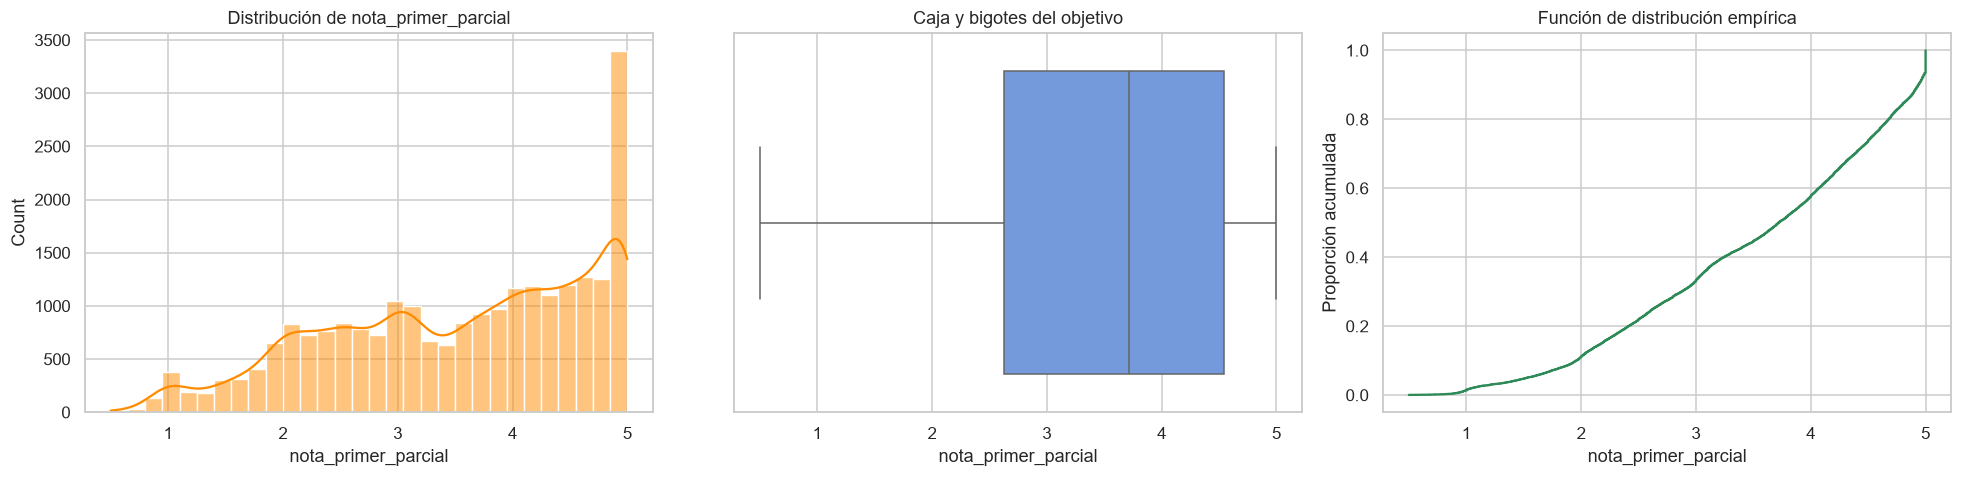

Interpretación:
- La mediana es 3.720 y la media es 3.532; la diferencia absoluta es 0.188.
- La asimetría es -0.445 y la curtosis de exceso es -0.865; valores negativos indican concentración hacia la parte alta y colas menos pesadas que una normal.
- El criterio IQR marca 0 observaciones (0.00 %); se inspeccionan, pero no se eliminan automáticamente.
- La prueba de normalidad usa 5,000 observaciones y entrega p=1.21e-166; el resultado no se usa como decisión aislada debido al tamaño muestral.
- Decisión documentada: No se aplica transformación: el objetivo está acotado a la escala de calificación y presenta asimetría y curtosis moderadas.


In [6]:
y = df[TARGET].dropna().astype(float)
target_q = y.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
target_iqr = target_q.loc[0.75] - target_q.loc[0.25]
target_lower = target_q.loc[0.25] - 1.5 * target_iqr
target_upper = target_q.loc[0.75] + 1.5 * target_iqr
target_outliers = ((y < target_lower) | (y > target_upper)).sum()
normal_stat, normal_p, normal_n = normality_pvalue(y)

target_summary = pd.Series({
    'n': len(y), 'media': y.mean(), 'mediana': y.median(), 'desviacion_estandar': y.std(),
    'minimo': y.min(), 'p01': target_q.loc[0.01], 'p05': target_q.loc[0.05],
    'p25': target_q.loc[0.25], 'p50': target_q.loc[0.50], 'p75': target_q.loc[0.75],
    'p95': target_q.loc[0.95], 'p99': target_q.loc[0.99], 'maximo': y.max(),
    'asimetria': y.skew(), 'curtosis_exceso': y.kurtosis(),
    'outliers_iqr': int(target_outliers), 'pct_outliers_iqr': 100 * target_outliers / len(y),
    'normaltest_p_muestra': normal_p, 'n_usado_normalidad': normal_n,
})
display(target_summary.to_frame('valor').round(4))

transform_diagnostics = []
if (y >= 0).all():
    log_values = np.log1p(y)
    transform_diagnostics.append({'transformacion': 'log1p', 'asimetria': log_values.skew(), 'curtosis_exceso': log_values.kurtosis()})
boxcox_values, boxcox_lambda = stats.boxcox(y - y.min() + 1e-6)
transform_diagnostics.append({'transformacion': f'Box-Cox (lambda={boxcox_lambda:.3f})', 'asimetria': pd.Series(boxcox_values).skew(), 'curtosis_exceso': pd.Series(boxcox_values).kurtosis()})
display(pd.DataFrame(transform_diagnostics).round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
sns.histplot(y, bins=min(30, y.nunique()), kde=True, color='darkorange', ax=axes[0])
axes[0].set_title(f'Distribución de {TARGET}')
sns.boxplot(x=y, color='cornflowerblue', ax=axes[1])
axes[1].set_title('Caja y bigotes del objetivo')
sorted_y = np.sort(y.to_numpy())
axes[2].plot(sorted_y, np.arange(1, len(sorted_y) + 1) / len(sorted_y), color='seagreen')
axes[2].set_title('Función de distribución empírica')
axes[2].set_xlabel(TARGET)
axes[2].set_ylabel('Proporción acumulada')
plt.tight_layout()
plt.show()

bounded_grade = y.min() >= 0 and y.max() <= 5.5
moderate_shape = abs(y.skew()) < 1.0 and abs(y.kurtosis()) < 1.5
if bounded_grade and moderate_shape:
    transform_decision = 'No se aplica transformación: el objetivo está acotado a la escala de calificación y presenta asimetría y curtosis moderadas.'
else:
    transform_decision = 'La transformación se deja como sensibilidad para el modelado posterior porque la forma observada supera al menos uno de los criterios descriptivos.'

print('Interpretación:')
print(f'- La mediana es {y.median():.3f} y la media es {y.mean():.3f}; la diferencia absoluta es {abs(y.mean() - y.median()):.3f}.')
print(f'- La asimetría es {y.skew():.3f} y la curtosis de exceso es {y.kurtosis():.3f}; valores negativos indican concentración hacia la parte alta y colas menos pesadas que una normal.')
print(f'- El criterio IQR marca {int(target_outliers):,} observaciones ({100 * target_outliers / len(y):.2f} %); se inspeccionan, pero no se eliminan automáticamente.')
print(f'- La prueba de normalidad usa {normal_n:,} observaciones y entrega p={normal_p:.3g}; el resultado no se usa como decisión aislada debido al tamaño muestral.')
print(f'- Decisión documentada: {transform_decision}')

## 5. Análisis unidimensional de variables numéricas

Para cada predictor numérico se reportan cardinalidad, estadísticos robustos y no robustos,
percentiles, asimetría, curtosis, prueba de normalidad cautelosa y outliers IQR. Los gráficos
permiten distinguir concentración, discretización, colas y valores extremos sin convertir un
outlier en un dato inválido por defecto.

,n,nulos,cardinalidad,media,mediana,desv_std,p01,p05,p25,p75,p95,p99,asimetria,curtosis_exceso,outliers_iqr,pct_outliers_iqr
variable,,,,,,,,,,,,,,,,
Dominio_Inicial,23942,0,103,8.9736,2.0000,15.4118,0.0000,0.0000,0.0000,10.0000,38.0000,72.0000,3.1722,13.7989,2661,11.1144
Tiempo_empleado_en_la_verificación_de_conocimientos,23529,413,22509,0.7360,0.5332,0.6172,0.0506,0.1383,0.3055,0.9592,2.0688,2.9039,1.7266,3.2954,1415,6.0139
Icfes_Matematicas,23942,0,63,68.4937,69.0000,10.0590,43.0000,53.0000,64.0000,74.0000,80.0000,100.0000,-1.0472,8.7267,1046,4.3689
Tiempo_total_Aprendidos_hora,23879,63,23410,1.5617,1.4298,0.9037,0.0000,0.3239,1.0077,1.9827,3.2083,4.6438,1.3524,3.8894,972,4.0705
Dominio_Final,23942,0,99,36.8296,33.0000,26.4585,0.0000,3.0000,17.0000,50.0000,79.0000,141.0000,1.1779,2.1319,486,2.0299
Tiempo_Total_Tiempo,23879,63,23547,18.4845,16.6114,12.6604,0.4348,2.4448,8.6764,25.6753,41.0848,56.5530,1.2510,3.8706,416,1.7421
Icfes_nuevo,23942,0,298,340.8982,345.0000,48.0976,222.0000,261.0000,313.0000,370.0000,417.0000,442.0000,-0.9906,5.4430,402,1.6791
avance_precalculo_aleks,23942,0,90,27.9399,27.0000,19.9999,0.0000,1.0000,11.0000,38.0000,67.0000,78.0000,0.8304,0.7419,209,0.8729
nota_primer_parcial,23942,0,443,3.5317,3.7200,1.1296,0.9700,1.5300,2.6300,4.5400,5.0000,5.0000,-0.4446,-0.8646,0,0.0000


,estadistico_normaltest,p_normaltest,n_prueba
variable,,,
Icfes_nuevo,1015.21784,0.0,5000
Icfes_Matematicas,1233.74079,0.0,5000
Tiempo_empleado_en_la_verificación_de_conocimientos,1653.06241,0.0,5000
Dominio_Inicial,3206.43683,0.0,5000
avance_precalculo_aleks,581.81966,0.0,5000
Dominio_Final,1015.34469,0.0,5000
Tiempo_Total_Tiempo,898.09857,0.0,5000
Tiempo_total_Aprendidos_hora,1339.19984,0.0,5000
nota_primer_parcial,764.07060,0.0,5000


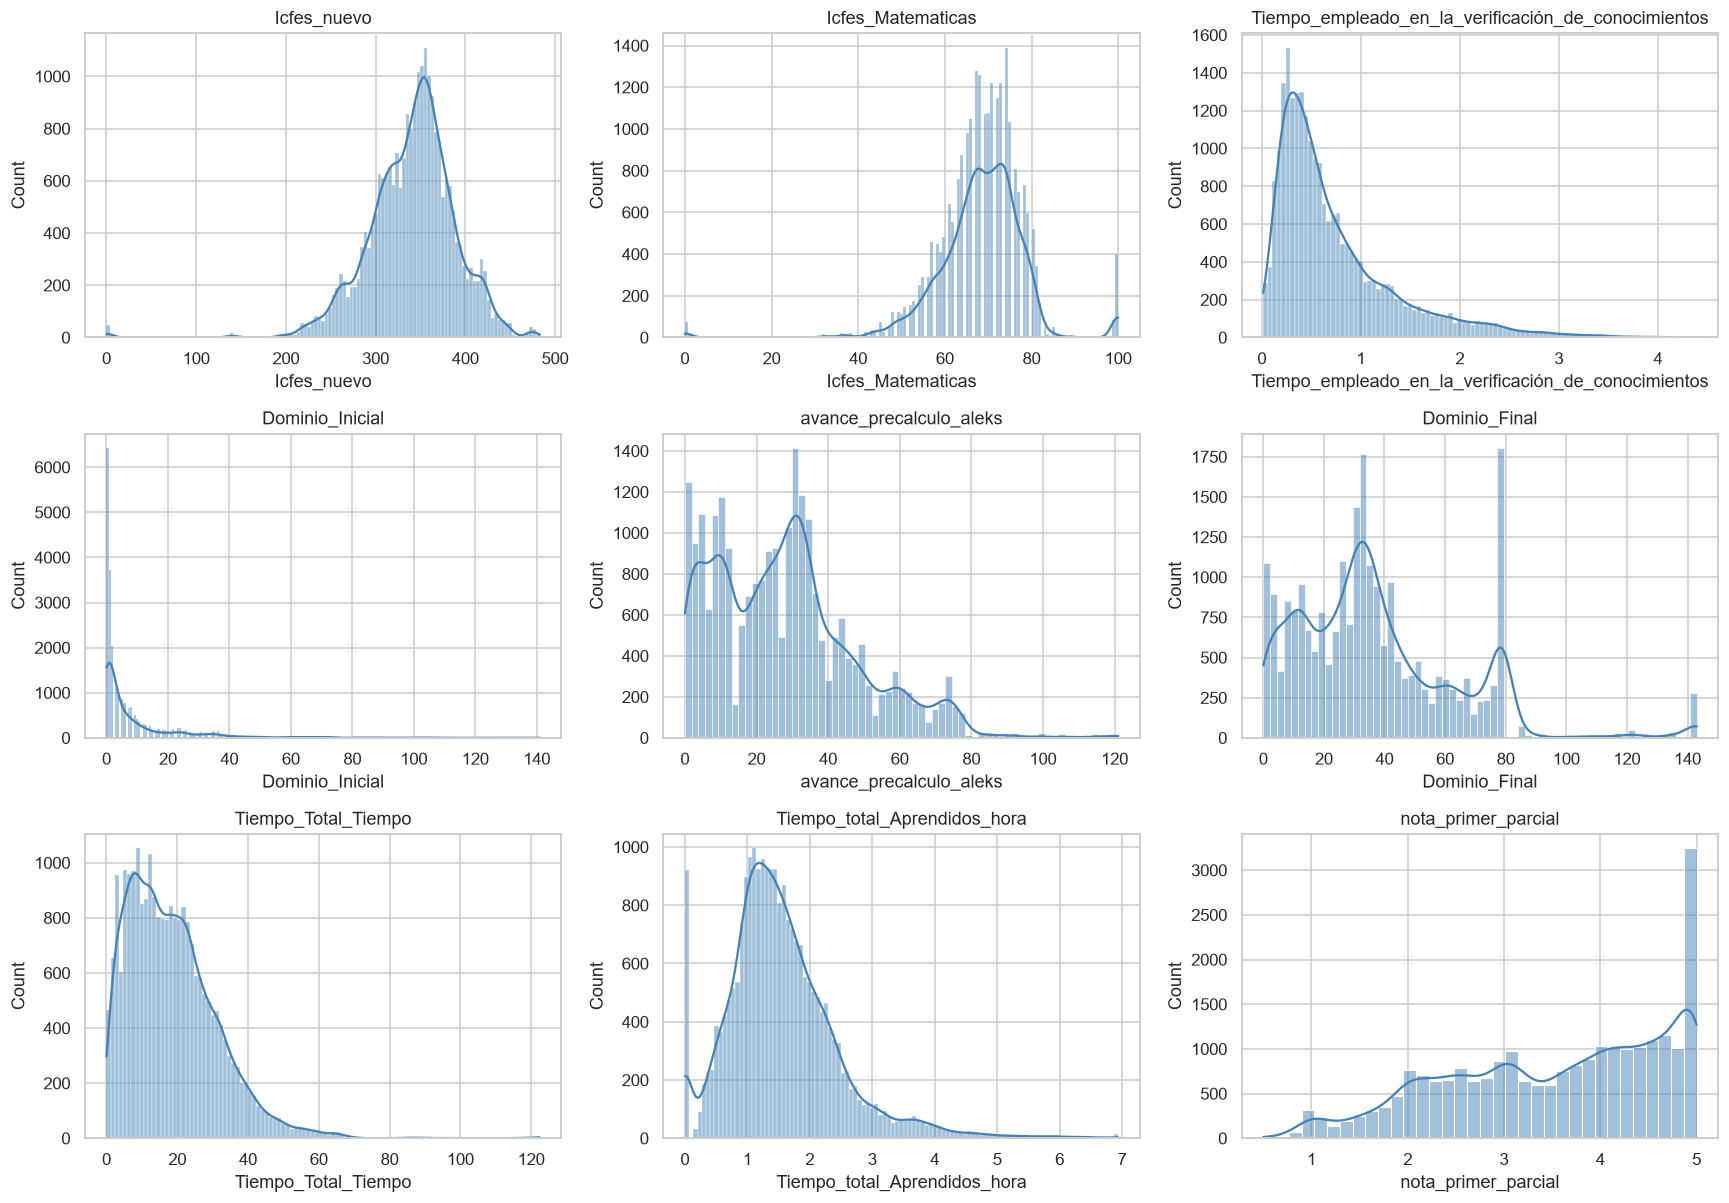

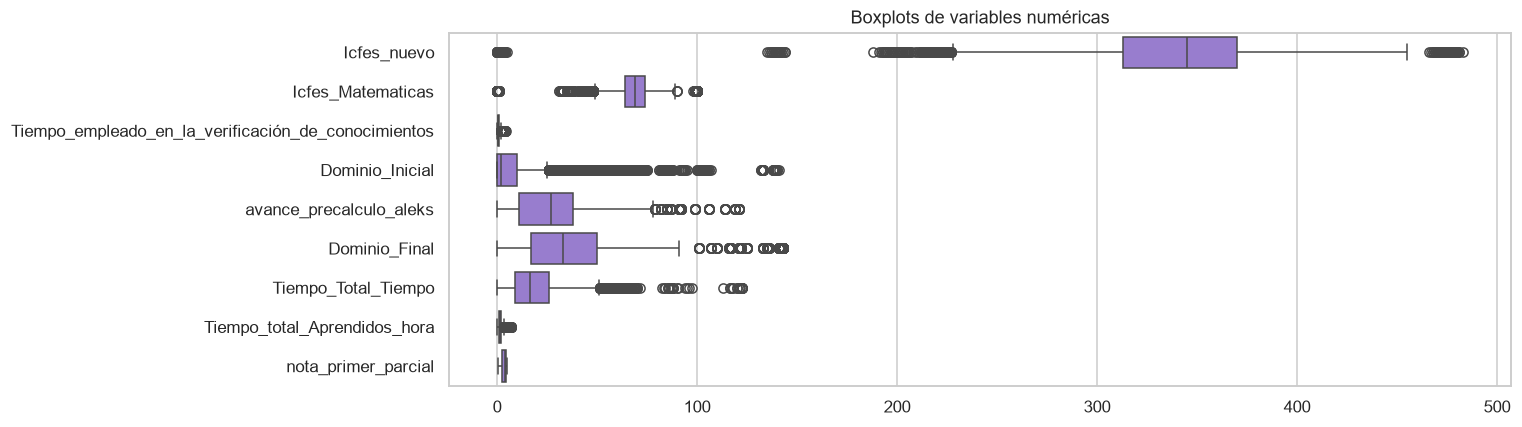

Interpretación:
- Variables con mayor asimetría absoluta: ['Dominio_Inicial', 'Tiempo_empleado_en_la_verificación_de_conocimientos', 'Tiempo_total_Aprendidos_hora'].
- Variables con mayor proporción de observaciones fuera de 1.5 IQR: ['Dominio_Inicial', 'Tiempo_empleado_en_la_verificación_de_conocimientos', 'Icfes_Matematicas'].
- Las pruebas de normalidad se reportan como referencia descriptiva; no se exige normalidad para aplicar modelos de regresión ni para conservar una variable.
- Los valores extremos se investigarán también en el espacio multivariado antes de decidir cualquier tratamiento.


In [7]:
numeric_eda_cols = numeric_feature_cols + [TARGET]
numeric_rows = []
normality_rows = []
for column in numeric_eda_cols:
    values = pd.to_numeric(df[column], errors='coerce')
    valid = values.dropna()
    q1, median, q3 = valid.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((valid < lower) | (valid > upper)).sum())
    numeric_rows.append({
        'variable': column, 'n': len(valid), 'nulos': int(values.isna().sum()),
        'cardinalidad': int(valid.nunique()), 'media': valid.mean(), 'mediana': median,
        'desv_std': valid.std(), 'p01': valid.quantile(0.01), 'p05': valid.quantile(0.05),
        'p25': q1, 'p75': q3, 'p95': valid.quantile(0.95), 'p99': valid.quantile(0.99),
        'asimetria': valid.skew(), 'curtosis_exceso': valid.kurtosis(),
        'outliers_iqr': n_out, 'pct_outliers_iqr': 100 * n_out / len(valid) if len(valid) else np.nan,
    })
    statistic, pvalue, n_test = normality_pvalue(valid)
    normality_rows.append({'variable': column, 'estadistico_normaltest': statistic, 'p_normaltest': pvalue, 'n_prueba': n_test})

numeric_profile = pd.DataFrame(numeric_rows).set_index('variable').sort_values('pct_outliers_iqr', ascending=False)
normality_profile = pd.DataFrame(normality_rows).set_index('variable')
display(numeric_profile.round(4))
display(normality_profile.round(5))

ncols = 3
nrows = math.ceil(len(numeric_eda_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.7 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, column in zip(axes, numeric_eda_cols):
    sns.histplot(df[column].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(column)
for ax in axes[len(numeric_eda_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, max(4, 0.45 * len(numeric_eda_cols))))
sns.boxplot(data=df[numeric_eda_cols], orient='h', ax=ax, color='mediumpurple')
ax.set_title('Boxplots de variables numéricas')
plt.tight_layout()
plt.show()

most_skewed = numeric_profile['asimetria'].abs().sort_values(ascending=False).head(3)
most_outliers = numeric_profile['pct_outliers_iqr'].head(3)
print('Interpretación:')
print(f'- Variables con mayor asimetría absoluta: {most_skewed.index.tolist()}.')
print(f'- Variables con mayor proporción de observaciones fuera de 1.5 IQR: {most_outliers.index.tolist()}.')
print('- Las pruebas de normalidad se reportan como referencia descriptiva; no se exige normalidad para aplicar modelos de regresión ni para conservar una variable.')
print('- Los valores extremos se investigarán también en el espacio multivariado antes de decidir cualquier tratamiento.')

## 6. Análisis unidimensional de variables categóricas

Se muestran cardinalidad, valores faltantes, frecuencias absolutas y relativas. Las categorías
raras se identifican para revisión: una categoría poco frecuente puede representar un subgrupo
real, un error de captura o una codificación inconsistente. Por eso no se colapsan
automáticamente; para el modelado, cualquier agrupación deberá definirse usando solo train y
documentando su justificación.

,cardinalidad,nulos_o_na,categorias_bajo_1_pct,pct_categoria_dominante,categoria_dominante
variable,,,,,
Categoria_temas_inicial,11,0,5,49.094,1 Repaso de álgebra y geometría
Categoria_temas_final,12,0,6,32.984,3 Temas Parcial 1 Cálculo I
programa_en_matricula,16,0,3,21.189,Ingeniería Sistemas Y Computac
division_en_matricula,6,0,1,54.206,División de Ingenierías
Mat_Curso_Asignatura_Relacionada,4,0,0,59.694,MAT1101
avance_cuartiles,16,0,5,25.566,1 Avance entre [ 19 - 40 temas]
cumplimiento_temas,2,0,0,52.005,Cumplimiento meta



=== Categoria_temas_inicial | 11 categorías ===


,frecuencia,porcentaje
Categoria_temas_inicial,,
1 Repaso de álgebra y geometría,11754,49.094
0 No dominó temas,6983,29.166
2 Ecuaciones y desigualdades,3296,13.767
3 Temas Parcial 1 Cálculo I,1125,4.699
4 Temas Parcial 2 Cálculo I,331,1.383
1 Geometría,259,1.082
3 Gráficos y funciones,72,0.301
"3 Plano de coordenadas, distancia y punto medio",39,0.163
4 Funciones polinómicas y racionales,36,0.15


Categorías raras (<1.0%): ['3 Gráficos y funciones', '3 Plano de coordenadas, distancia y punto medio', '4 Funciones polinómicas y racionales', '2 Ecuaciones racionales que se reducen a lineales', '4 Pendientes y ecuaciones de rectas']

=== Categoria_temas_final | 12 categorías ===


,frecuencia,porcentaje
Categoria_temas_final,,
3 Temas Parcial 1 Cálculo I,7897,32.984
2 Ecuaciones y desigualdades,6903,28.832
4 Temas Parcial 2 Cálculo I,4167,17.405
1 Repaso de Álgebra y Geometría,3423,14.297
0 No dominó temas,679,2.836
5 Funciones trigonométricas,279,1.165
"3 Plano de coordenadas, distancia y punto medio",183,0.764
3 Gráficos y funciones,180,0.752
4 Pendientes y ecuaciones de rectas,108,0.451


...

,frecuencia,porcentaje
Mat_Curso_Asignatura_Relacionada,,
MAT1101,14292,59.694
MAT1100,8262,34.508
MAT4190,1028,4.294
MAT1011,360,1.504



=== avance_cuartiles | 16 categorías ===


,frecuencia,porcentaje
avance_cuartiles,,
1 Avance entre [ 19 - 40 temas],6121,25.566
0 Avance menor a 19 temas,4573,19.1
0 Avance menor a 18 temas,3389,14.155
1 Avance entre [ 18 - 37 temas],3204,13.382
2 Avance entre [ 40 - 60 temas],2281,9.527
3 Avance superior a 60 temas,1317,5.501
2 Avance entre [ 37 - 55 temas],1239,5.175
3 Avance superior a 55 temas,430,1.796
1 Avance entre [ 25 - 55 temas],314,1.312


Categorías raras (<1.0%): ['3 Avance superior a 80 temas', '0 Avance menor a 15 temas', '2 Avance entre [ 23 - 29 temas]', '3 Avance superior a 29 temas', '1 Avance entre [ 15 - 23 temas]']

=== cumplimiento_temas | 2 categorías ===


,frecuencia,porcentaje
cumplimiento_temas,,
Cumplimiento meta,12451,52.005
No alcanzo meta,11491,47.995


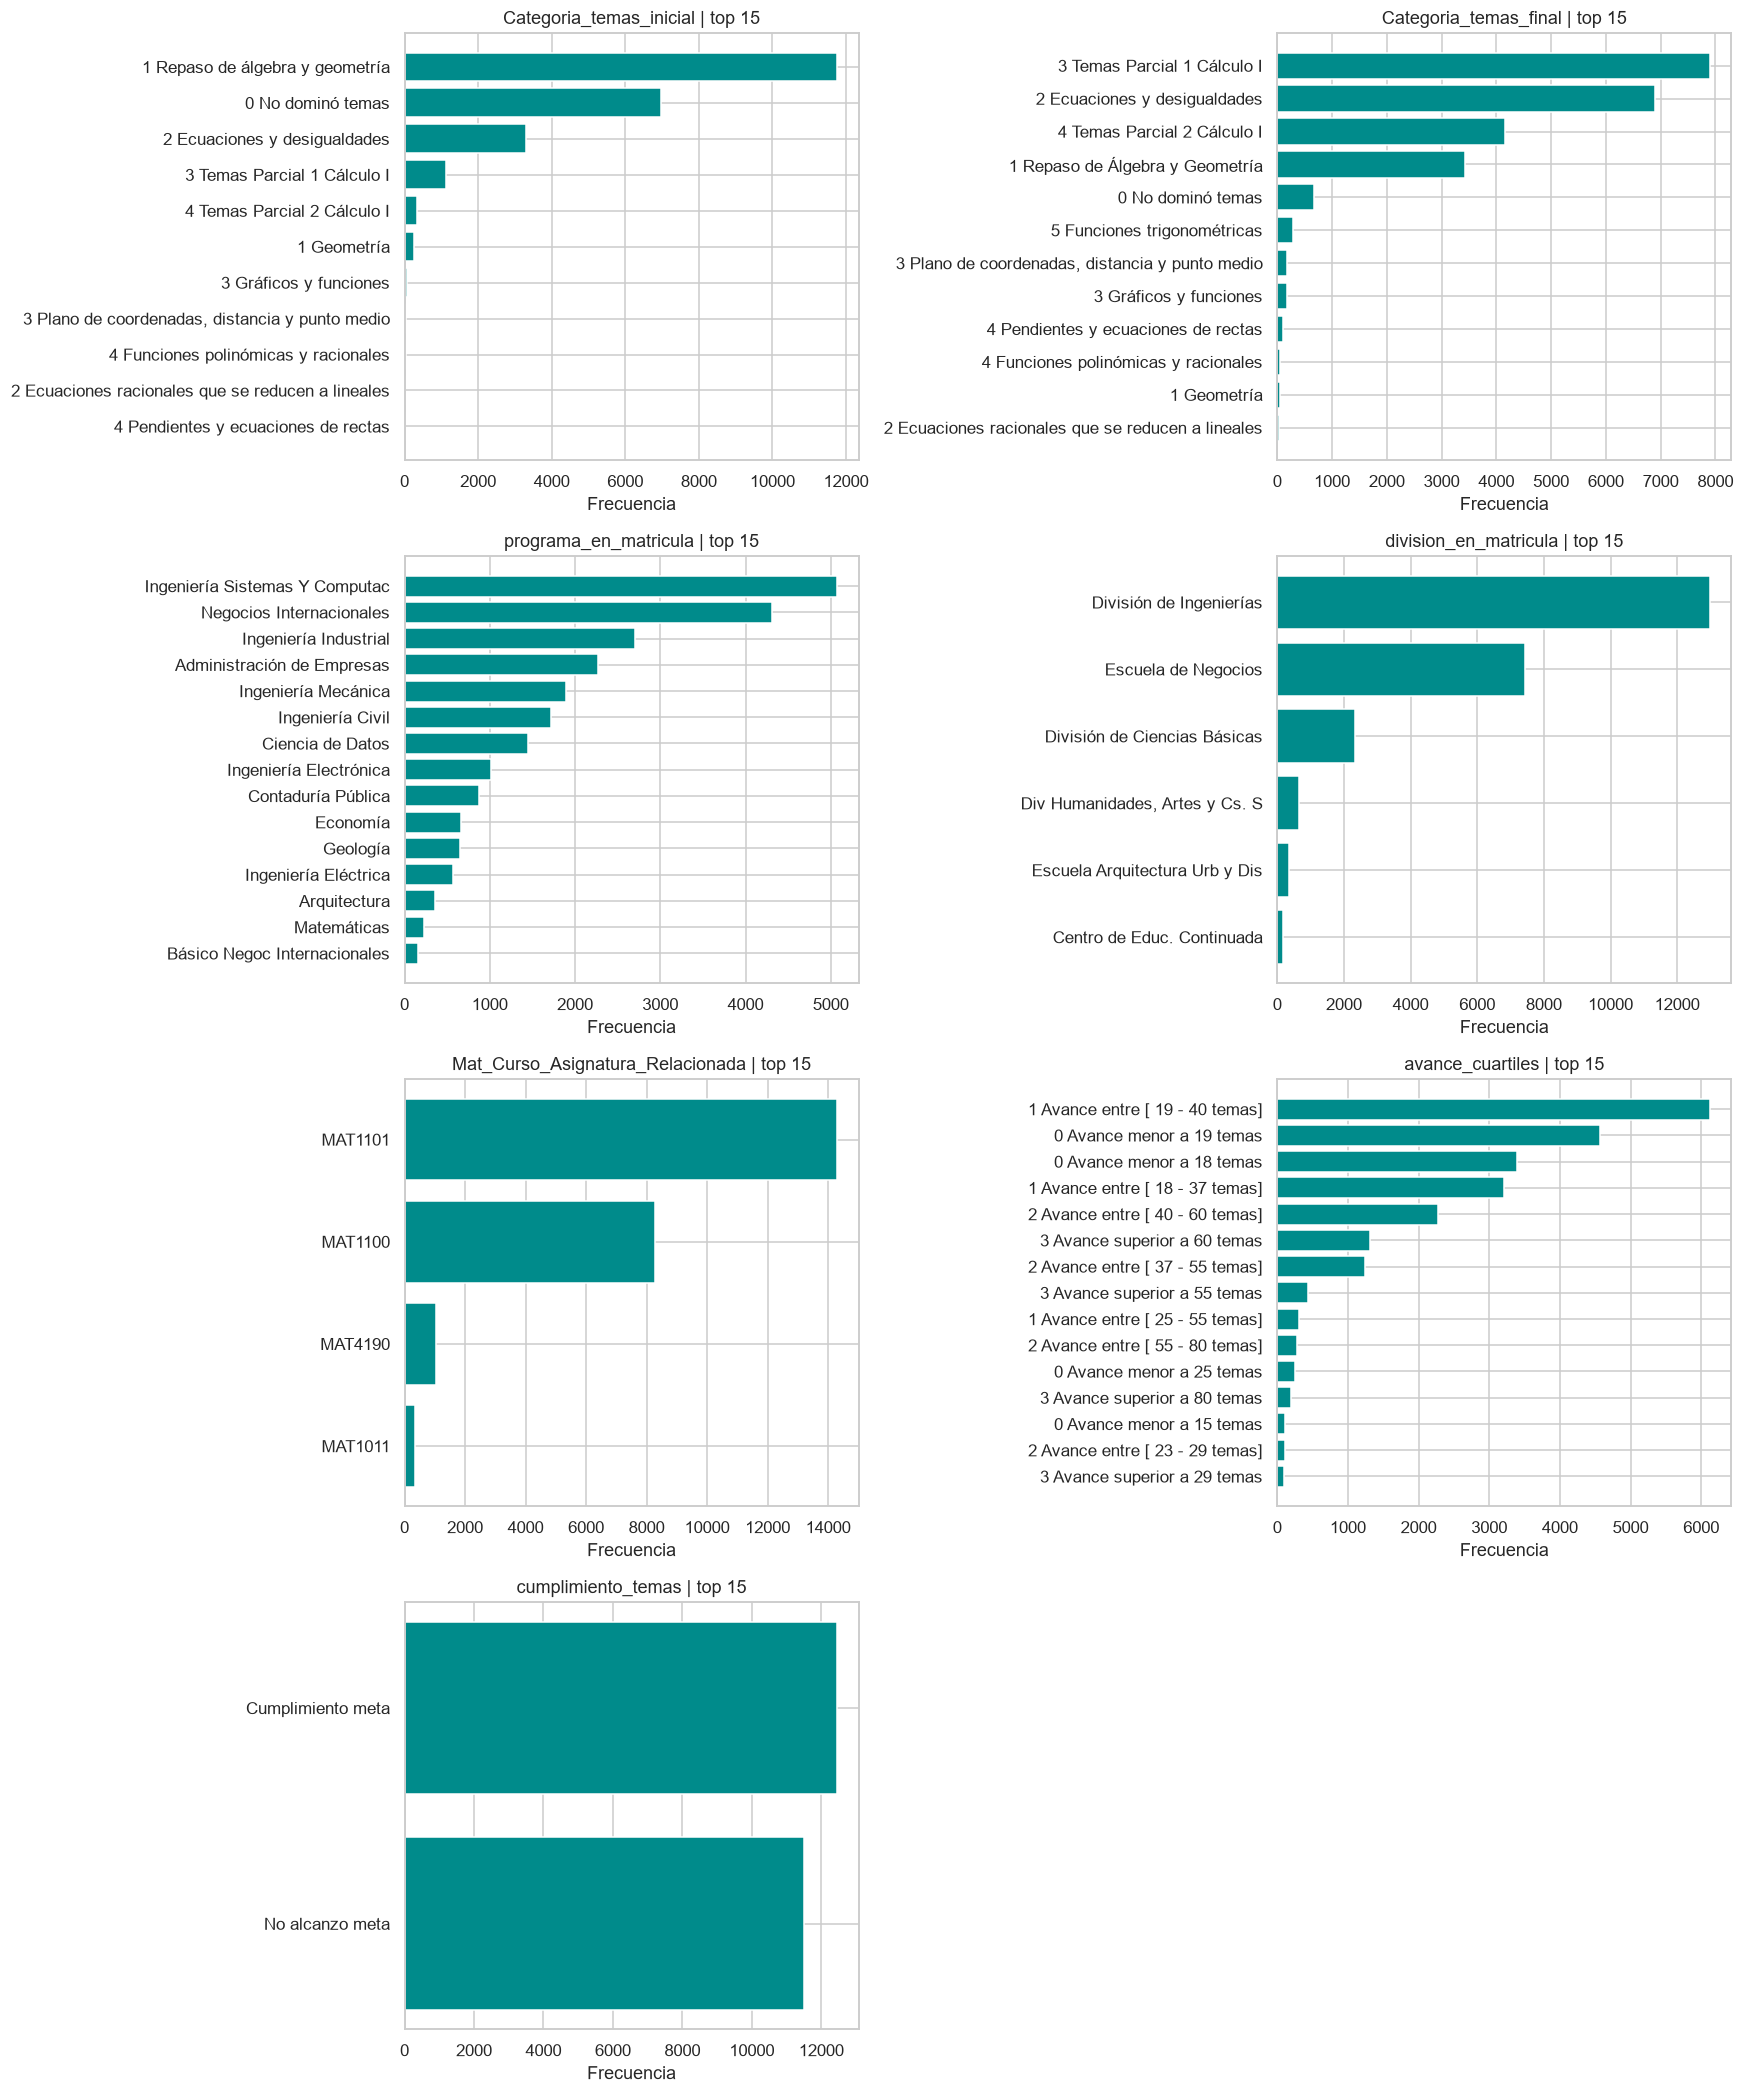

Interpretación:
- Se detectaron 20 categorías con menos de 1.0 % de las filas, distribuidas en 5 variables.
- La recomendación inicial es conservarlas durante el EDA, verificar si son errores de rotulación y, si procede, agruparlas como categoría rara dentro de un transformador ajustado solo con train.


In [8]:
categorical_summary_rows = []
rare_categories = {}
for column in categorical_feature_cols:
    values = value_label(df[column])
    frequencies = values.value_counts(dropna=False)
    proportions = frequencies / len(values)
    rare = proportions[proportions < RARE_CATEGORY_THRESHOLD]
    rare_categories[column] = rare
    categorical_summary_rows.append({
        'variable': column, 'cardinalidad': int(values.nunique()),
        'nulos_o_na': int((values == '<NA>').sum()),
        'categorias_bajo_1_pct': int(len(rare)),
        'pct_categoria_dominante': 100 * proportions.iloc[0],
        'categoria_dominante': str(frequencies.index[0]),
    })

categorical_profile = pd.DataFrame(categorical_summary_rows).set_index('variable')
display(categorical_profile.round(3))

for column in categorical_feature_cols:
    frequencies = value_label(df[column]).value_counts(dropna=False)
    table = pd.DataFrame({'frecuencia': frequencies, 'porcentaje': 100 * frequencies / len(df)})
    print(f'\n=== {column} | {len(frequencies)} categorías ===')
    display(table.head(20).round(3))
    if len(rare_categories[column]):
        print(f'Categorías raras (<{100 * RARE_CATEGORY_THRESHOLD:.1f}%): {rare_categories[column].index.tolist()}')

ncols = 2
nrows = math.ceil(len(categorical_feature_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, column in zip(axes, categorical_feature_cols):
    values = value_label(df[column]).value_counts().head(15).sort_values()
    ax.barh(values.index.astype(str), values.values, color='darkcyan')
    ax.set_title(f'{column} | top 15')
    ax.set_xlabel('Frecuencia')
for ax in axes[len(categorical_feature_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()

rare_count = sum(len(values) for values in rare_categories.values())
print('Interpretación:')
print(f'- Se detectaron {rare_count} categorías con menos de {100 * RARE_CATEGORY_THRESHOLD:.1f} % de las filas, distribuidas en {sum(len(values) > 0 for values in rare_categories.values())} variables.')
print('- La recomendación inicial es conservarlas durante el EDA, verificar si son errores de rotulación y, si procede, agruparlas como categoría rara dentro de un transformador ajustado solo con train.')

## 7. Análisis bidimensional: numéricas frente a numéricas

Se calculan correlaciones de Pearson y Spearman, junto con sus valores p, tamaños de asociación
y medidas de información mutua para captar relaciones no lineales. Los gráficos usan
transparencia y una muestra reproducible cuando es necesario para evitar sobrecarga visual.

,pearson_r,p_pearson,spearman_rho,p_spearman,mutual_info,n,q_pearson,q_spearman
variable,,,,,,,,
Dominio_Final,0.42676,0.0,0.46194,0.0,0.59176,23942,0.0,0.0
avance_precalculo_aleks,0.29683,0.0,0.29141,0.0,0.47405,23942,0.0,0.0
Icfes_nuevo,0.48922,0.0,0.52747,0.0,0.33954,23942,0.0,0.0
Icfes_Matematicas,0.33928,0.0,0.41129,0.0,0.23635,23942,0.0,0.0
Dominio_Inicial,0.34432,0.0,0.46170,0.0,0.21885,23942,0.0,0.0
Tiempo_total_Aprendidos_hora,0.32406,0.0,0.36583,0.0,0.21130,23879,0.0,0.0
Tiempo_empleado_en_la_verificación_de_conocimientos,0.32660,0.0,0.35807,0.0,0.20916,23529,0.0,0.0
Tiempo_Total_Tiempo,0.07067,0.0,0.06978,0.0,0.16332,23879,0.0,0.0


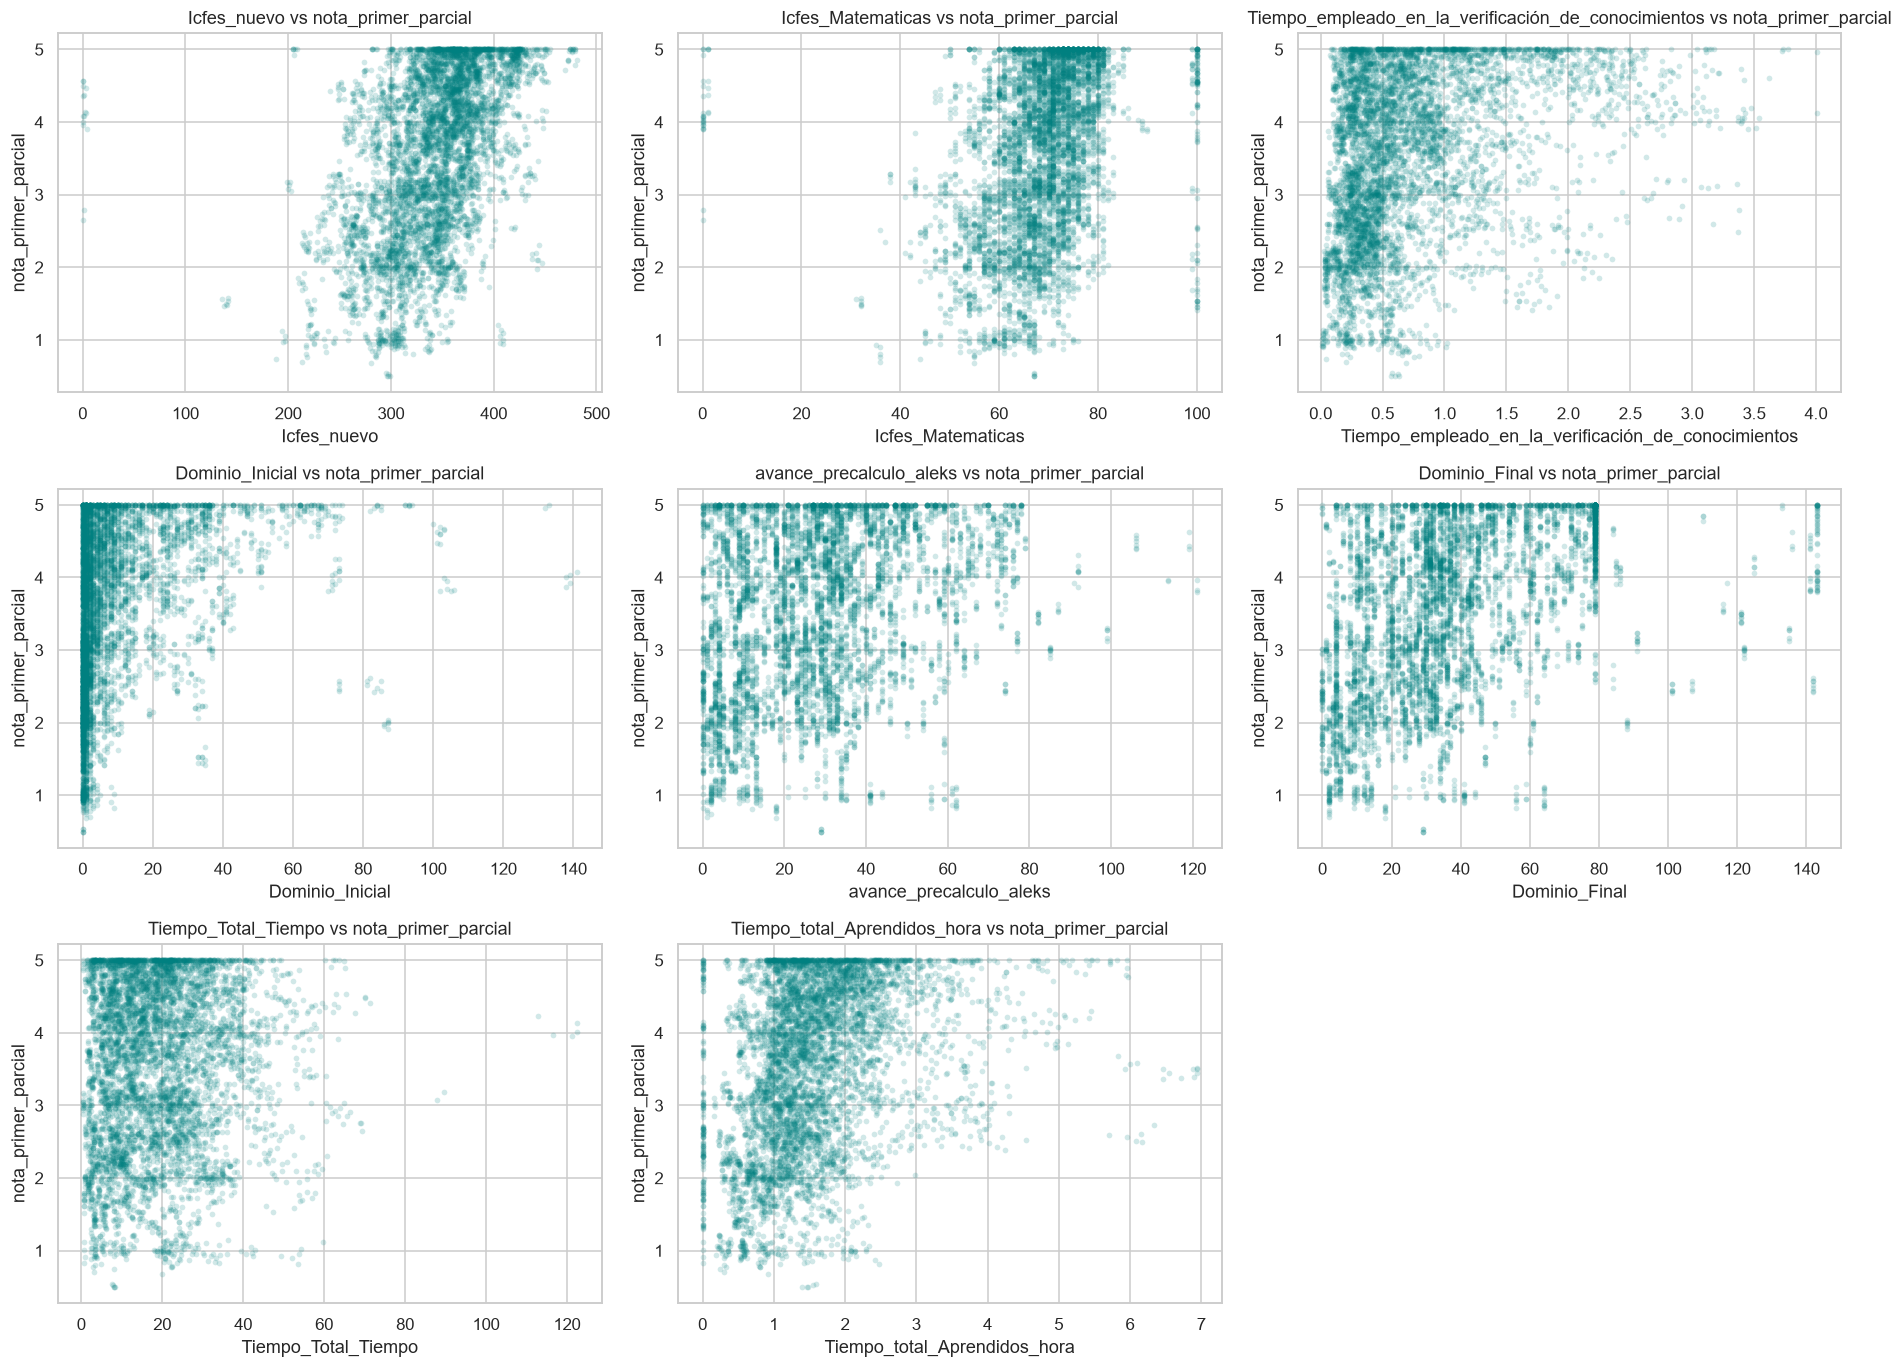

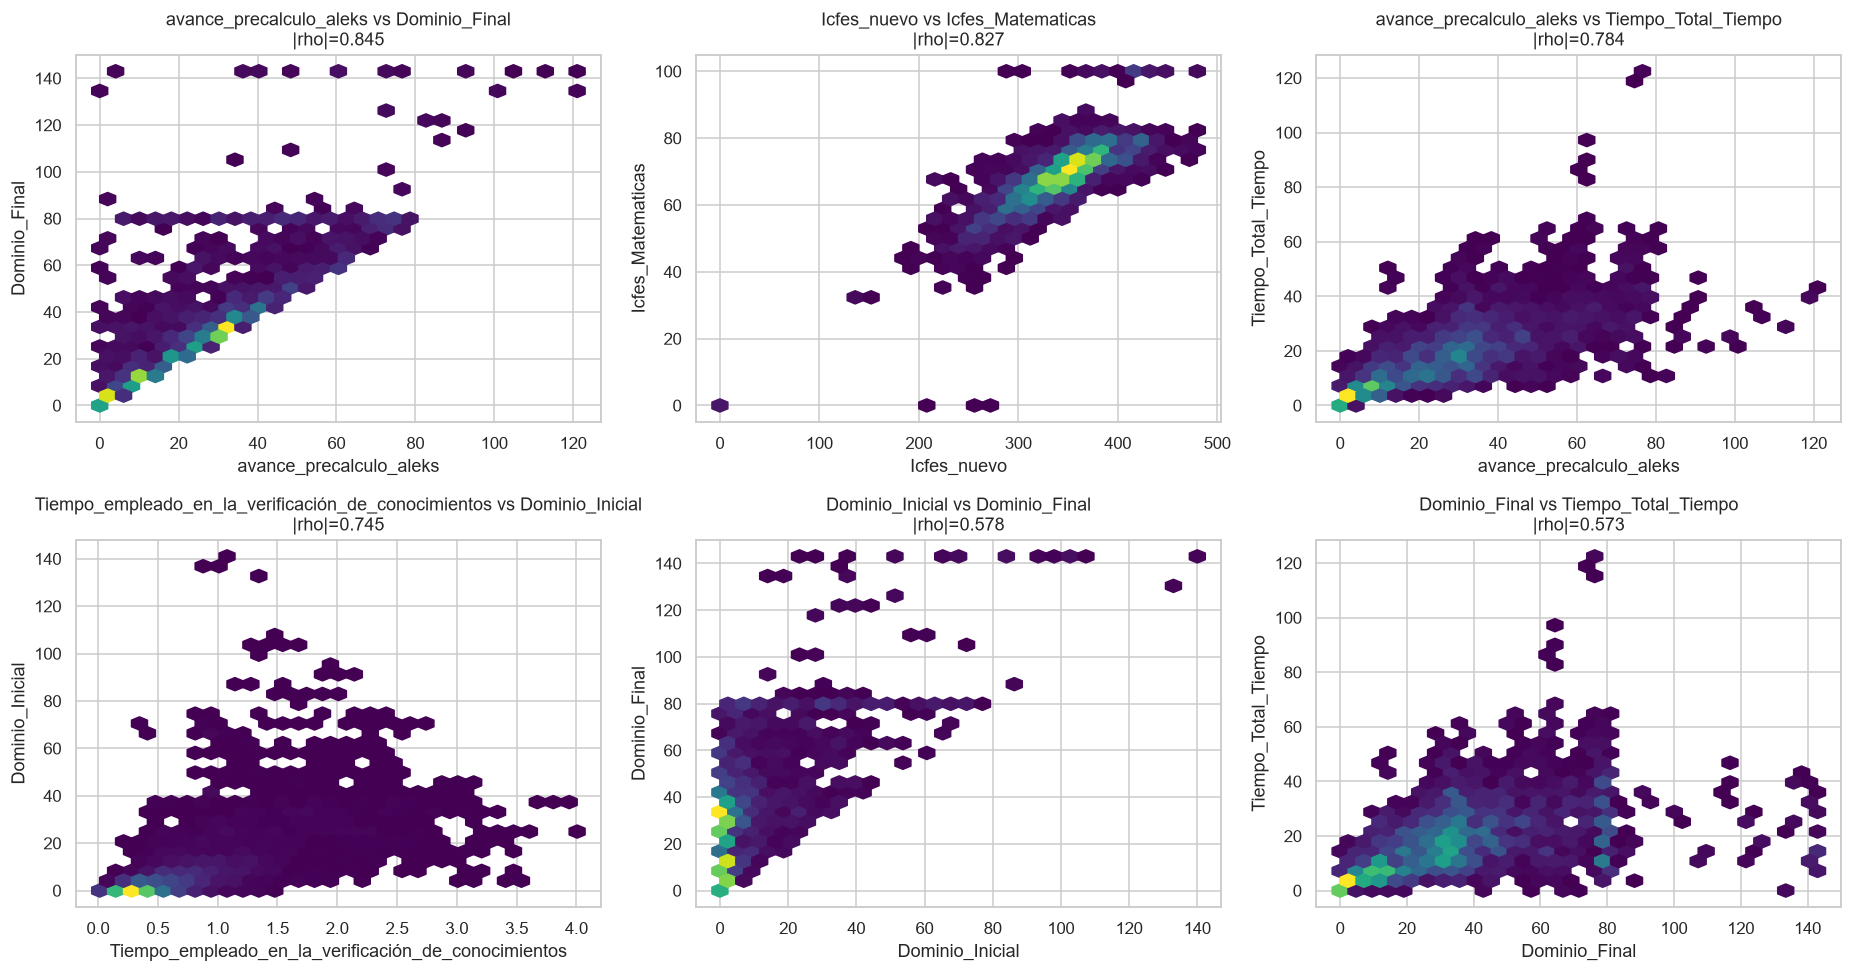

Interpretación:
- Mayores asociaciones monotónicas con el objetivo: ['Icfes_nuevo', 'Dominio_Final', 'Dominio_Inicial'].
- Mayores señales de dependencia potencialmente no lineal según información mutua: ['Dominio_Final', 'avance_precalculo_aleks', 'Icfes_nuevo'].
- Si Spearman supera claramente a Pearson, la relación puede ser monotónica pero no lineal; si la información mutua es alta con correlación baja, se requiere inspección gráfica antes de descartar la variable.


In [9]:
numeric_target_rows = []
for column in numeric_feature_cols:
    pair = df[[column, TARGET]].dropna()
    if len(pair) < 20 or pair[column].nunique() < 2:
        continue
    pearson_result = stats.pearsonr(pair[column], pair[TARGET])
    spearman_result = stats.spearmanr(pair[column], pair[TARGET])
    numeric_target_rows.append({
        'variable': column, 'pearson_r': pearson_result.statistic, 'p_pearson': pearson_result.pvalue,
        'spearman_rho': spearman_result.statistic, 'p_spearman': spearman_result.pvalue,
        'mutual_info': safe_mi_numeric(df[column], df[TARGET]), 'n': len(pair),
    })

numeric_target_assoc = pd.DataFrame(numeric_target_rows).set_index('variable')
numeric_target_assoc['q_pearson'] = fdr_bh(numeric_target_assoc['p_pearson'])
numeric_target_assoc['q_spearman'] = fdr_bh(numeric_target_assoc['p_spearman'])
display(numeric_target_assoc.sort_values('mutual_info', ascending=False).round(5))

complete_numeric_target = df[numeric_feature_cols + [TARGET]].dropna()
sample = complete_numeric_target.sample(min(6000, len(complete_numeric_target)), random_state=RANDOM_STATE)
ncols = 3
nrows = math.ceil(len(numeric_feature_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, column in zip(axes, numeric_feature_cols):
    sns.scatterplot(data=sample, x=column, y=TARGET, alpha=0.18, s=14, linewidth=0, ax=ax, color='teal')
    ax.set_title(f'{column} vs {TARGET}')
for ax in axes[len(numeric_feature_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()

feature_corr = df[numeric_feature_cols].corr(method='spearman').abs()
candidate_pairs = sorted(
    [(feature_corr.loc[left, right], left, right) for left, right in combinations(numeric_feature_cols, 2)],
    reverse=True,
)[:6]
if candidate_pairs:
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    axes = axes.ravel()
    for ax, (association, left, right) in zip(axes, candidate_pairs):
        pair = df[[left, right]].dropna()
        if len(pair) > 6000:
            pair = pair.sample(6000, random_state=RANDOM_STATE)
        ax.hexbin(pair[left], pair[right], gridsize=30, mincnt=1, cmap='viridis')
        ax.set_title(f'{left} vs {right}\n|rho|={association:.3f}')
        ax.set_xlabel(left)
        ax.set_ylabel(right)
    for ax in axes[len(candidate_pairs):]:
        ax.remove()
    plt.tight_layout()
    plt.show()

top_linear = numeric_target_assoc['spearman_rho'].abs().sort_values(ascending=False).head(3)
top_nonlinear = numeric_target_assoc['mutual_info'].sort_values(ascending=False).head(3)
print('Interpretación:')
print(f'- Mayores asociaciones monotónicas con el objetivo: {top_linear.index.tolist()}.')
print(f'- Mayores señales de dependencia potencialmente no lineal según información mutua: {top_nonlinear.index.tolist()}.')
print('- Si Spearman supera claramente a Pearson, la relación puede ser monotónica pero no lineal; si la información mutua es alta con correlación baja, se requiere inspección gráfica antes de descartar la variable.')

## 8. Análisis bidimensional: categóricas frente a numéricas

Para cada combinación de variable categórica y variable numérica se calcula Kruskal-Wallis,
adecuado cuando no se desea asumir normalidad dentro de cada grupo, y el tamaño de efecto
epsilon cuadrado. La tabla permite priorizar diferencias prácticas y no solo p-valores. La
variable objetivo recibe una visualización específica por categoría.

,categorica,numerica,n_grupos,n,H_kruskal,p_kruskal,epsilon2,eta2,q_kruskal
49,avance_cuartiles,avance_precalculo_aleks,16,23942,21197.19616,0.0,0.88532,0.92019,0.0
14,Categoria_temas_final,Dominio_Final,12,23942,19680.83394,0.0,0.82197,0.86322,0.0
3,Categoria_temas_inicial,Dominio_Inicial,11,23942,17258.06822,0.0,0.72074,0.73012,0.0
50,avance_cuartiles,Dominio_Final,16,23942,16455.15732,0.0,0.68713,0.70829,0.0
13,Categoria_temas_final,avance_precalculo_aleks,12,23942,15404.50668,0.0,0.64327,0.63048,0.0
59,cumplimiento_temas,Dominio_Final,2,23942,14553.21713,0.0,0.60786,0.39114,0.0
51,avance_cuartiles,Tiempo_Total_Tiempo,16,23879,14019.89035,0.0,0.58689,0.52697,0.0
58,cumplimiento_temas,avance_precalculo_aleks,2,23942,11647.12429,0.0,0.48647,0.38097,0.0
2,Categoria_temas_inicial,Tiempo_empleado_en_la_verificación_de_conocimientos,11,23529,10652.95437,0.0,0.45255,0.49207,0.0
15,Categoria_temas_final,Tiempo_Total_Tiempo,12,23879,9733.39256,0.0,0.40736,0.33996,0.0


,categorica,n_grupos,n,p_kruskal,q_kruskal,epsilon2,eta2
8,Categoria_temas_inicial,11,23942,0.0,0.0,0.23420,0.22958
17,Categoria_temas_final,12,23942,0.0,0.0,0.21923,0.21298
62,cumplimiento_temas,2,23942,0.0,0.0,0.14449,0.14302
53,avance_cuartiles,16,23942,0.0,0.0,0.12522,0.12595
26,programa_en_matricula,16,23942,0.0,0.0,0.05380,0.05791
35,division_en_matricula,6,23942,0.0,0.0,0.02643,0.02474
44,Mat_Curso_Asignatura_Relacionada,4,23942,0.0,0.0,0.02129,0.02063


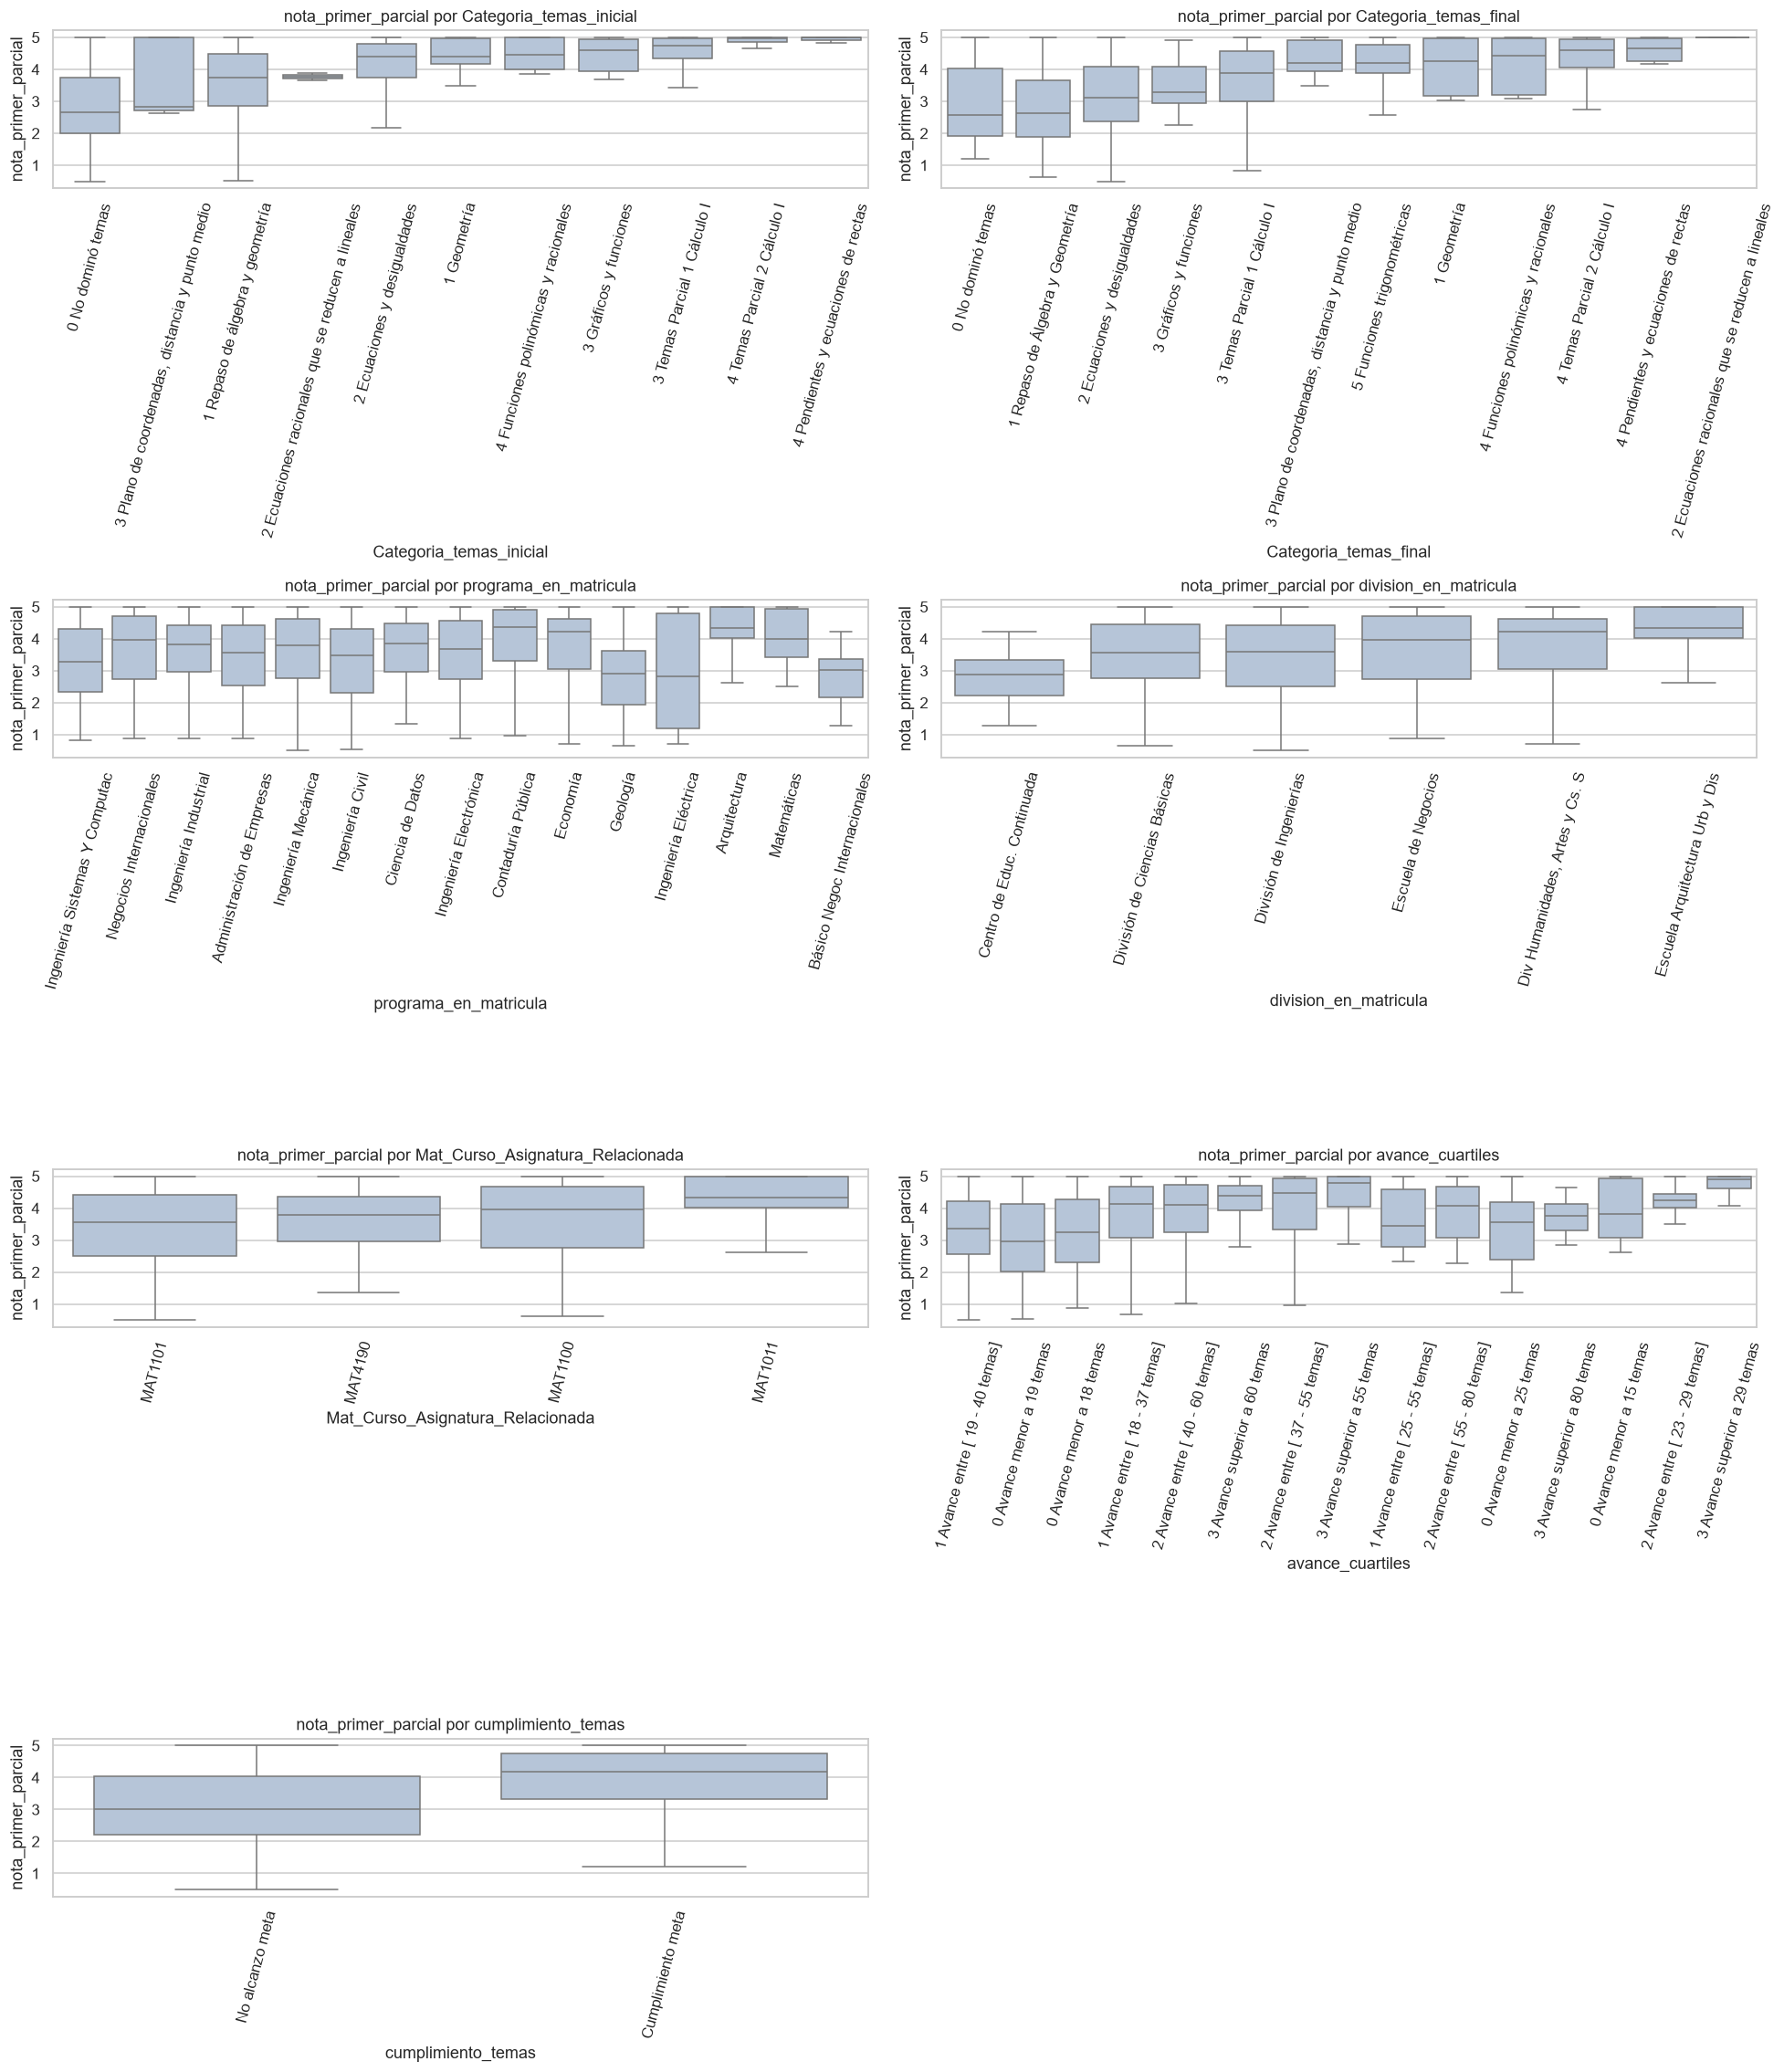

Interpretación:
- Mayores tamaños de efecto categórica–objetivo: ['Categoria_temas_inicial', 'Categoria_temas_final', 'cumplimiento_temas'].
- El mayor epsilon cuadrado observado es 0.2342; representa la fracción aproximada de variación rank-based asociada con los grupos.
- La corrección FDR se aplica sobre todas las comparaciones categórica–numérica, porque el número de pruebas es elevado.


In [10]:
cat_num_rows = []
for cat in categorical_feature_cols:
    for num in numeric_feature_cols + [TARGET]:
        pair = df[[cat, num]].dropna().copy()
        pair[cat] = value_label(pair[cat])
        groups = [group[num].to_numpy() for _, group in pair.groupby(cat, observed=True) if len(group) >= 2]
        if len(groups) < 2:
            continue
        kruskal_result = stats.kruskal(*groups)
        cat_num_rows.append({
            'categorica': cat, 'numerica': num, 'n_grupos': len(groups), 'n': len(pair),
            'H_kruskal': kruskal_result.statistic, 'p_kruskal': kruskal_result.pvalue,
            'epsilon2': epsilon_squared_kruskal(kruskal_result.statistic, groups, len(pair)),
            'eta2': eta_squared(groups),
        })

cat_num_assoc = pd.DataFrame(cat_num_rows)
cat_num_assoc['q_kruskal'] = fdr_bh(cat_num_assoc['p_kruskal'])
cat_num_assoc = cat_num_assoc.sort_values(['epsilon2', 'eta2'], ascending=False)
display(cat_num_assoc.head(30).round(5))

target_group_effects = cat_num_assoc[cat_num_assoc['numerica'] == TARGET].copy()
display(target_group_effects[['categorica', 'n_grupos', 'n', 'p_kruskal', 'q_kruskal', 'epsilon2', 'eta2']].round(5))

ncols = 2
nrows = math.ceil(len(categorical_feature_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5.2 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, cat in zip(axes, categorical_feature_cols):
    plot_data = df[[cat, TARGET]].copy()
    plot_data[cat] = value_label(plot_data[cat])
    order = plot_data.groupby(cat, observed=True)[TARGET].median().sort_values().index
    if len(order) > 15:
        order = plot_data[cat].value_counts().head(15).index
    sns.boxplot(data=plot_data[plot_data[cat].isin(order)], x=cat, y=TARGET, order=order, ax=ax, color='lightsteelblue', showfliers=False)
    ax.set_title(f'{TARGET} por {cat}')
    ax.tick_params(axis='x', rotation=75)
for ax in axes[len(categorical_feature_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()

top_group_effects = target_group_effects.sort_values('epsilon2', ascending=False).head(3)
print('Interpretación:')
if len(top_group_effects):
    print(f'- Mayores tamaños de efecto categórica–objetivo: {top_group_effects.categorica.tolist()}.')
    print(f'- El mayor epsilon cuadrado observado es {top_group_effects.iloc[0].epsilon2:.4f}; representa la fracción aproximada de variación rank-based asociada con los grupos.')
else:
    print('- No se pudo calcular una comparación con grupos suficientes.')
print('- La corrección FDR se aplica sobre todas las comparaciones categórica–numérica, porque el número de pruebas es elevado.')

## 9. Análisis bidimensional: categóricas frente a categóricas

Cada par de variables categóricas se resume con tabla de contingencia, prueba chi-cuadrado y V de
Cramer corregida. La prueba indica si existe evidencia de asociación; V de Cramer cuantifica su
magnitud y evita interpretar una asociación estadísticamente significativa como necesariamente
importante.

,categorica_1,categorica_2,filas,columnas,chi2,gl,p_chi2,v_cramer,celdas_esperadas_menor_5_pct,q_chi2
10,Categoria_temas_final,cumplimiento_temas,12,2,23942.00000,11,0.0,0.99979,0.00000,0.0
11,programa_en_matricula,division_en_matricula,16,6,119710.00000,75,0.0,0.99979,13.54167,0.0
18,Mat_Curso_Asignatura_Relacionada,avance_cuartiles,4,16,71826.00000,45,0.0,0.99975,18.75000,0.0
12,programa_en_matricula,Mat_Curso_Asignatura_Relacionada,16,4,61997.10022,45,0.0,0.92878,6.25000,0.0
15,division_en_matricula,Mat_Curso_Asignatura_Relacionada,6,4,57447.21521,15,0.0,0.89426,4.16667,0.0
8,Categoria_temas_final,Mat_Curso_Asignatura_Relacionada,12,4,38326.80931,33,0.0,0.73021,22.91667,0.0
16,division_en_matricula,avance_cuartiles,6,16,58011.45032,75,0.0,0.69575,22.91667,0.0
20,avance_cuartiles,cumplimiento_temas,16,2,11031.93422,15,0.0,0.67836,0.00000,0.0
3,Categoria_temas_inicial,Mat_Curso_Asignatura_Relacionada,11,4,27126.09599,30,0.0,0.61424,27.27273,0.0
9,Categoria_temas_final,avance_cuartiles,12,16,89400.56852,165,0.0,0.58223,40.10417,0.0


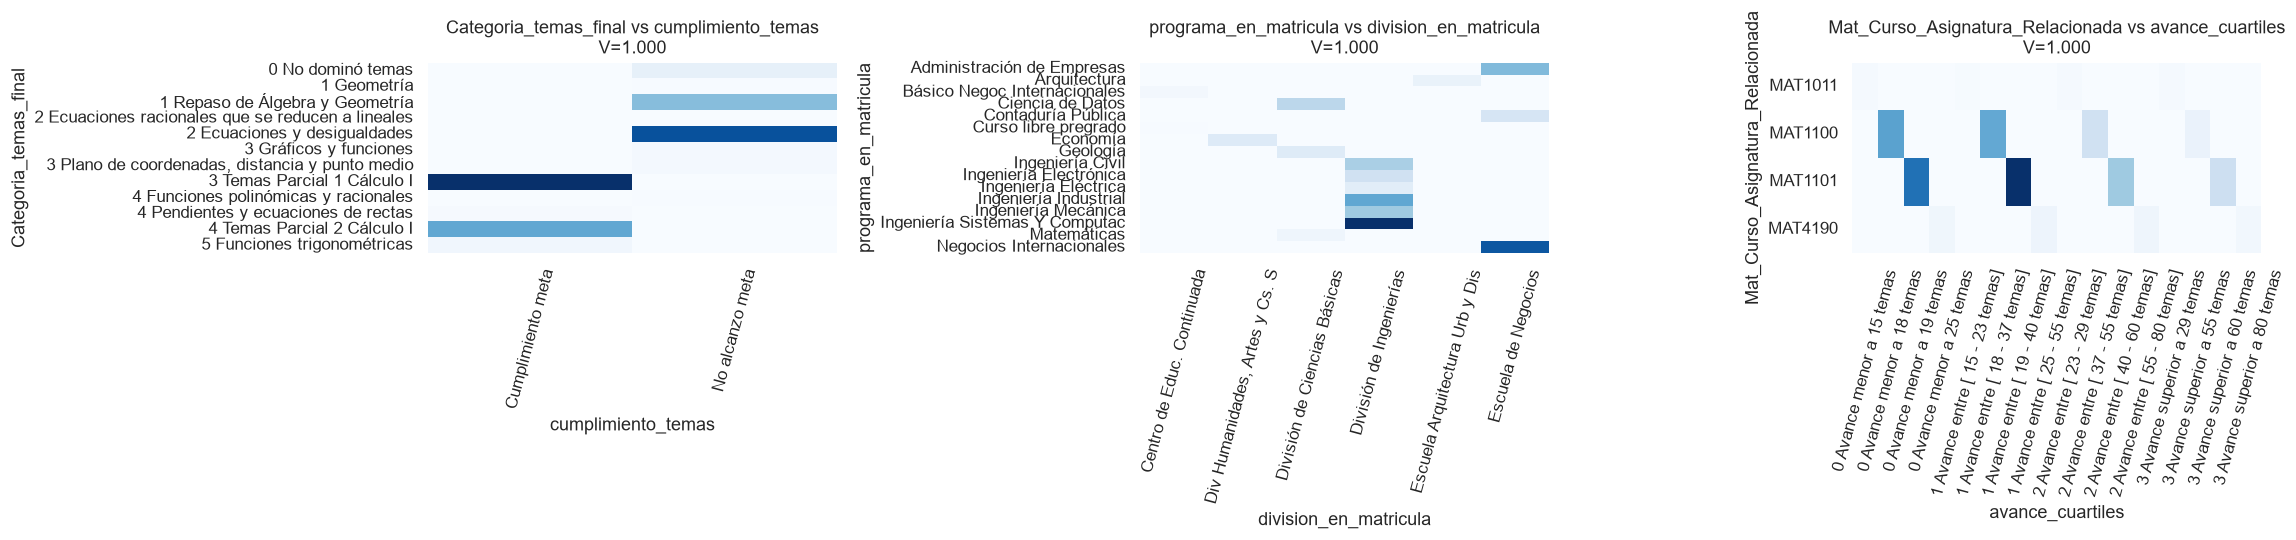

Interpretación:
- La mayor asociación categórica es Categoria_temas_final–cumplimiento_temas, con V de Cramer=0.9998.
- El 0.0 % de sus celdas tiene frecuencia esperada inferior a 5; la chi-cuadrado debe interpretarse con esta advertencia.
- La corrección FDR controla el problema de realizar múltiples pruebas de independencia.


In [11]:
cat_cat_rows = []
cat_cat_tables = {}
for left, right in combinations(categorical_feature_cols, 2):
    table = pd.crosstab(value_label(df[left]), value_label(df[right]))
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue
    chi2, pvalue, dof, expected = stats.chi2_contingency(table, correction=False)
    cat_cat_rows.append({
        'categorica_1': left, 'categorica_2': right, 'filas': table.shape[0], 'columnas': table.shape[1],
        'chi2': chi2, 'gl': dof, 'p_chi2': pvalue, 'v_cramer': cramers_v(table.to_numpy()),
        'celdas_esperadas_menor_5_pct': 100 * (expected < 5).mean(),
    })
    cat_cat_tables[(left, right)] = table

cat_cat_assoc = pd.DataFrame(cat_cat_rows)
cat_cat_assoc['q_chi2'] = fdr_bh(cat_cat_assoc['p_chi2'])
cat_cat_assoc = cat_cat_assoc.sort_values('v_cramer', ascending=False)
display(cat_cat_assoc.round(5))

top_cat_pairs = cat_cat_assoc.head(3)
if len(top_cat_pairs):
    fig, axes = plt.subplots(1, len(top_cat_pairs), figsize=(7 * len(top_cat_pairs), 5))
    axes = np.atleast_1d(axes)
    for ax, row in zip(axes, top_cat_pairs.itertuples()):
        table = cat_cat_tables[(row.categorica_1, row.categorica_2)]
        sns.heatmap(table, cmap='Blues', ax=ax, cbar=False)
        ax.set_title(f'{row.categorica_1} vs {row.categorica_2}\nV={row.v_cramer:.3f}')
        ax.tick_params(axis='x', rotation=75)
        ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.show()

print('Interpretación:')
if len(cat_cat_assoc):
    strongest = cat_cat_assoc.iloc[0]
    print(f'- La mayor asociación categórica es {strongest.categorica_1}–{strongest.categorica_2}, con V de Cramer={strongest.v_cramer:.4f}.')
    print(f'- El {strongest.celdas_esperadas_menor_5_pct:.1f} % de sus celdas tiene frecuencia esperada inferior a 5; la chi-cuadrado debe interpretarse con esta advertencia.')
print('- La corrección FDR controla el problema de realizar múltiples pruebas de independencia.')

## 10. Asociaciones de las predictoras con la variable objetivo

Se consolida una vista específica para la selección preliminar, sin convertirla todavía en una
selección definitiva. Para numéricas se incluyen Pearson, Spearman e información mutua; para
categóricas se incluyen Kruskal-Wallis, tamaño de efecto e información mutua. La información
mutua detecta dependencia general, pero no informa por sí sola causalidad, dirección ni
disponibilidad temporal.

In [12]:
target_assoc_rows = []
for column in numeric_feature_cols:
    if column not in numeric_target_assoc.index:
        continue
    row = numeric_target_assoc.loc[column]
    target_assoc_rows.append({
        'variable': column, 'tipo': 'numérica', 'pearson_o_efecto': row['pearson_r'],
        'spearman': row['spearman_rho'], 'p': row['p_spearman'], 'mutual_info': row['mutual_info'],
        'tamano_efecto': abs(row['spearman_rho']),
    })
for column in categorical_feature_cols:
    row = target_group_effects[target_group_effects['categorica'] == column]
    if row.empty:
        continue
    row = row.iloc[0]
    target_assoc_rows.append({
        'variable': column, 'tipo': 'categórica', 'pearson_o_efecto': np.nan, 'spearman': np.nan,
        'p': row['p_kruskal'], 'mutual_info': safe_mi_categorical(df[column], df[TARGET]),
        'tamano_efecto': row['epsilon2'],
    })

target_associations = pd.DataFrame(target_assoc_rows).set_index('variable')
target_associations['q_fdr'] = fdr_bh(target_associations['p'])
target_associations = target_associations.sort_values(['mutual_info', 'tamano_efecto'], ascending=False)
display(target_associations.round(5))

candidate_by_association = target_associations[
    (target_associations['tamano_efecto'].abs() >= 0.20)
    | (target_associations['mutual_info'] >= target_associations['mutual_info'].quantile(0.75))
].index.tolist()
print('Interpretación:')
print(f'- Variables candidatas para revisión preliminar por asociación estadística o no lineal: {candidate_by_association}.')
print('- Esta lista no es la lista final de predictores: antes de modelar se debe cruzar con disponibilidad en el momento de predicción, fuga, redundancia y estabilidad entre particiones.')

,tipo,pearson_o_efecto,spearman,p,mutual_info,tamano_efecto,q_fdr
variable,,,,,,,
Dominio_Final,numérica,0.42676,0.46194,0.0,0.59176,0.46194,0.0
avance_precalculo_aleks,numérica,0.29683,0.29141,0.0,0.47405,0.29141,0.0
Icfes_nuevo,numérica,0.48922,0.52747,0.0,0.33954,0.52747,0.0
Icfes_Matematicas,numérica,0.33928,0.41129,0.0,0.23635,0.41129,0.0
Dominio_Inicial,numérica,0.34432,0.46170,0.0,0.21885,0.46170,0.0
Tiempo_total_Aprendidos_hora,numérica,0.32406,0.36583,0.0,0.21130,0.36583,0.0
Tiempo_empleado_en_la_verificación_de_conocimientos,numérica,0.32660,0.35807,0.0,0.20916,0.35807,0.0
Categoria_temas_final,categórica,NaN,NaN,0.0,0.17947,0.21923,0.0
Categoria_temas_inicial,categórica,NaN,NaN,0.0,0.16345,0.23420,0.0


Interpretación:
- Variables candidatas para revisión preliminar por asociación estadística o no lineal: ['Dominio_Final', 'avance_precalculo_aleks', 'Icfes_nuevo', 'Icfes_Matematicas', 'Dominio_Inicial', 'Tiempo_total_Aprendidos_hora', 'Tiempo_empleado_en_la_verificación_de_conocimientos', 'Categoria_temas_final', 'Categoria_temas_inicial'].
- Esta lista no es la lista final de predictores: antes de modelar se debe cruzar con disponibilidad en el momento de predicción, fuga, redundancia y estabilidad entre particiones.


## 11. Matriz de correlación y multicolinealidad

La matriz se calcula solo sobre variables numéricas predictoras y el objetivo; nota_final se
mantiene fuera. Pearson resume asociación lineal y Spearman asociación monotónica. Los VIF se
calculan sobre las predictoras numéricas imputadas con la mediana del train exclusivamente. Un VIF
alto no obliga por sí mismo a eliminar una variable, pero señala redundancia y posible
inestabilidad en modelos lineales.

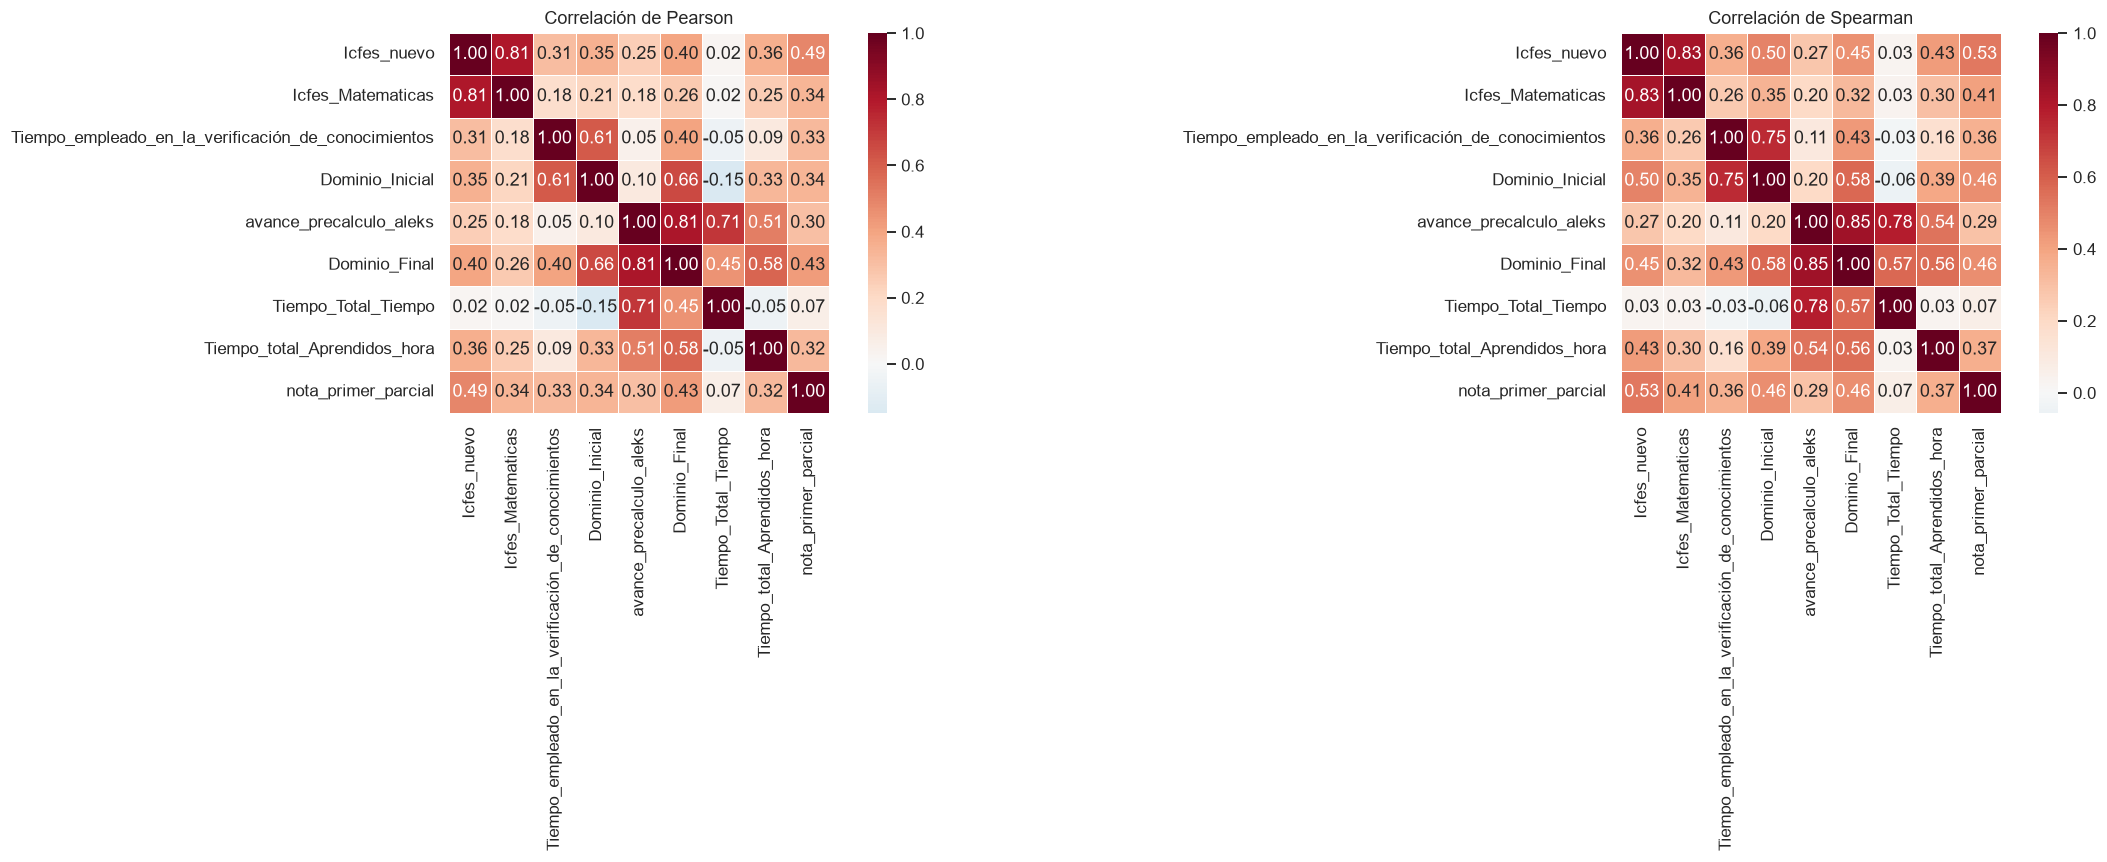

,VIF
variable,
Dominio_Final,1158.9362
avance_precalculo_aleks,670.4909
Dominio_Inicial,392.3285
Tiempo_Total_Tiempo,3.8536
Icfes_nuevo,3.4479
Icfes_Matematicas,2.9607
Tiempo_total_Aprendidos_hora,2.7049
Tiempo_empleado_en_la_verificación_de_conocimientos,1.7031


,variable_1,variable_2,spearman
1,avance_precalculo_aleks,Dominio_Final,0.8451
0,Icfes_nuevo,Icfes_Matematicas,0.8272


Interpretación:
- El VIF máximo es 1158.936 para Dominio_Final.
- Las correlaciones altas y los VIF deben considerarse conjuntamente con la interpretabilidad y la disponibilidad temporal; no se elimina una variable únicamente por significancia estadística.
- nota_final no aparece en ninguna matriz de correlación utilizada para orientar el modelado.


In [13]:
corr_cols = numeric_feature_cols + [TARGET]
pearson_matrix = df[corr_cols].corr(method='pearson')
spearman_matrix = df[corr_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
sns.heatmap(pearson_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.4, ax=axes[0])
axes[0].set_title('Correlación de Pearson')
sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.4, ax=axes[1])
axes[1].set_title('Correlación de Spearman')
plt.tight_layout()
plt.show()

X_num = df[numeric_feature_cols].copy().fillna(df[numeric_feature_cols].median())
X_standard = StandardScaler().fit_transform(X_num)
correlation_numeric = np.corrcoef(X_standard, rowvar=False)
vif_values = np.diag(np.linalg.pinv(correlation_numeric))
vif_profile = pd.DataFrame({'variable': numeric_feature_cols, 'VIF': vif_values}).set_index('variable').sort_values('VIF', ascending=False)
display(vif_profile.round(4))

high_corr_pairs = []
for left, right in combinations(numeric_feature_cols, 2):
    rho = spearman_matrix.loc[left, right]
    if abs(rho) >= CORRELATION_ALERT:
        high_corr_pairs.append({'variable_1': left, 'variable_2': right, 'spearman': rho})
if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs).sort_values('spearman', key=lambda values: values.abs(), ascending=False).round(4))
else:
    print(f'No se detectaron pares con |Spearman| >= {CORRELATION_ALERT:.2f}.')

print('Interpretación:')
print(f'- El VIF máximo es {vif_profile.iloc[0].VIF:.3f} para {vif_profile.index[0]}.')
print('- Las correlaciones altas y los VIF deben considerarse conjuntamente con la interpretabilidad y la disponibilidad temporal; no se elimina una variable únicamente por significancia estadística.')
print('- nota_final no aparece en ninguna matriz de correlación utilizada para orientar el modelado.')

## 12. Análisis multivariado: PCA exploratorio

PCA se aplica después de imputar y estandarizar numéricas y de codificar categóricas, todo
ajustado exclusivamente sobre train. La finalidad es explorar dimensionalidad efectiva y
redundancia; no se interpreta como prueba inferencial ni se incorpora todavía al modelo.

,componente,varianza_explicada,varianza_acumulada
0,1,0.30202,0.30202
1,2,0.15409,0.45611
2,3,0.10271,0.55882
3,4,0.08611,0.64493
4,5,0.07354,0.71848
5,6,0.03965,0.75813
6,7,0.03236,0.79048
7,8,0.02557,0.81605
8,9,0.02127,0.83732
9,10,0.01727,0.85459


Matriz codificada: 23,942 filas x 75 columnas.
Dimensiones necesarias para umbrales de varianza: {'80%': 8, '90%': 14, '95%': 21}


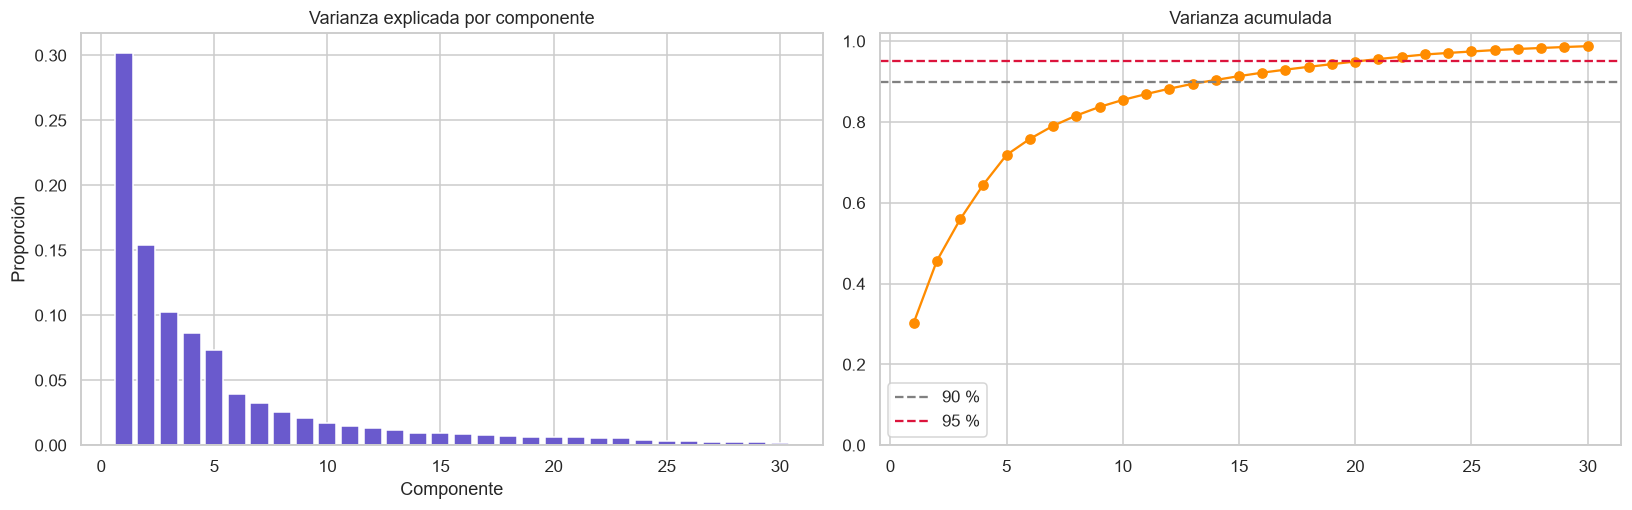

Interpretación:
- La representación codificada tiene 75 dimensiones y los primeros 21 componentes alcanzan el umbral de 95 % en el tramo calculado.
- Una dimensionalidad efectiva menor que la dimensionalidad codificada sugiere redundancia; las categorías one-hot siguen requiriendo validación de estabilidad y disponibilidad.


In [14]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_dense_ohe()),
])
eda_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_feature_cols),
        ('categorical', categorical_transformer, categorical_feature_cols),
    ],
    remainder='drop',
)
X_encoded = eda_preprocessor.fit_transform(df[feature_cols])
max_components = min(30, X_encoded.shape[0] - 1, X_encoded.shape[1])
pca = PCA(n_components=max_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_encoded)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)
effective_dims = {
    f'{int(threshold * 100)}%': int(np.searchsorted(cumulative, threshold) + 1)
    if cumulative[-1] >= threshold else np.nan
    for threshold in [0.80, 0.90, 0.95]
}
pca_profile = pd.DataFrame({
    'componente': np.arange(1, len(explained) + 1),
    'varianza_explicada': explained,
    'varianza_acumulada': cumulative,
})
display(pca_profile.head(15).round(5))
print(f'Matriz codificada: {X_encoded.shape[0]:,} filas x {X_encoded.shape[1]} columnas.')
print(f'Dimensiones necesarias para umbrales de varianza: {effective_dims}')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].bar(pca_profile['componente'], pca_profile['varianza_explicada'], color='slateblue')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Proporción')
axes[1].plot(pca_profile['componente'], pca_profile['varianza_acumulada'], marker='o', color='darkorange')
axes[1].axhline(0.90, color='gray', linestyle='--', label='90 %')
axes[1].axhline(0.95, color='crimson', linestyle='--', label='95 %')
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Varianza acumulada')
axes[1].legend()
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'- La representación codificada tiene {X_encoded.shape[1]} dimensiones y los primeros {effective_dims.get("95%", "más de 30")} componentes alcanzan el umbral de 95 % en el tramo calculado.')
print('- Una dimensionalidad efectiva menor que la dimensionalidad codificada sugiere redundancia; las categorías one-hot siguen requiriendo validación de estabilidad y disponibilidad.')

## 13. Análisis multivariado: outliers

Se aplican dos perspectivas complementarias. La distancia de Mahalanobis resume posiciones
atípicas en el espacio numérico estandarizado; Isolation Forest busca observaciones aisladas en el
espacio codificado de predictoras. Ambos métodos son herramientas de revisión: no se eliminan
filas automáticamente y se compara la incidencia con el objetivo únicamente para priorizar
inspección.

,metodo,n_outliers,pct_outliers,media_target_outliers
0,Mahalanobis numérico,1507,6.2944,3.9639
1,Isolation Forest codificado,869,3.6296,4.0215


Observaciones detectadas por ambos métodos: 524.


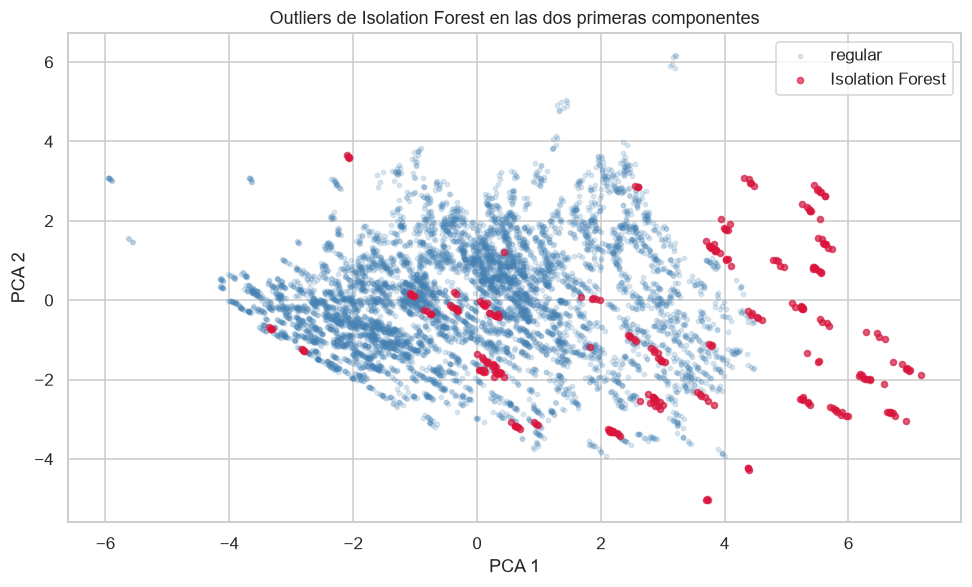

Interpretación:
- Para este ejercicio no se eliminan outliers: representan comportamiento real de la población y se conservan para el análisis y el modelado posterior.
- Una diferencia entre Mahalanobis e Isolation Forest es esperable: el primero resume una geometría elíptica numérica y el segundo detecta aislamiento en el espacio codificado.
- Antes del modelado se debe verificar si los casos extremos son registros válidos, subpoblaciones reales o errores de captura.


In [15]:
X_num_values = X_num.to_numpy(dtype=float)
covariance_inverse = np.linalg.pinv(np.cov(X_num_values, rowvar=False))
centered = X_num_values - X_num_values.mean(axis=0)
mahalanobis_squared = np.einsum('ij,jk,ik->i', centered, covariance_inverse, centered)
mahalanobis_threshold = stats.chi2.ppf(0.99, df=len(numeric_feature_cols))
mahalanobis_flag = mahalanobis_squared > mahalanobis_threshold

isolation_forest = IsolationForest(n_estimators=200, contamination='auto', random_state=RANDOM_STATE, n_jobs=-1)
isolation_prediction = isolation_forest.fit_predict(X_encoded)
isolation_flag = isolation_prediction == -1

outlier_profile = pd.DataFrame({
    'distancia_mahalanobis2': mahalanobis_squared,
    'outlier_mahalanobis_99pct': mahalanobis_flag,
    'outlier_isolation_forest': isolation_flag,
    TARGET: y.to_numpy(),
})
display(pd.DataFrame({
    'metodo': ['Mahalanobis numérico', 'Isolation Forest codificado'],
    'n_outliers': [int(mahalanobis_flag.sum()), int(isolation_flag.sum())],
    'pct_outliers': [100 * mahalanobis_flag.mean(), 100 * isolation_flag.mean()],
    'media_target_outliers': [outlier_profile.loc[mahalanobis_flag, TARGET].mean(), outlier_profile.loc[isolation_flag, TARGET].mean()],
}).round(4))
print(f'Observaciones detectadas por ambos métodos: {int((mahalanobis_flag & isolation_flag).sum())}.')

plot_sample_idx = np.arange(len(df))
if len(df) > 8000:
    plot_sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(df), 8000, replace=False)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(X_pca[plot_sample_idx, 0], X_pca[plot_sample_idx, 1], s=8, alpha=0.18, color='steelblue', label='regular')
flag_idx = plot_sample_idx[isolation_flag[plot_sample_idx]]
ax.scatter(X_pca[flag_idx, 0], X_pca[flag_idx, 1], s=16, alpha=0.65, color='crimson', label='Isolation Forest')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_title('Outliers de Isolation Forest en las dos primeras componentes')
ax.legend()
plt.tight_layout()
plt.show()

print('Interpretación:')
print('- Para este ejercicio no se eliminan outliers: representan comportamiento real de la población y se conservan para el análisis y el modelado posterior.')
print('- Una diferencia entre Mahalanobis e Isolation Forest es esperable: el primero resume una geometría elíptica numérica y el segundo detecta aislamiento en el espacio codificado.')
print('- Antes del modelado se debe verificar si los casos extremos son registros válidos, subpoblaciones reales o errores de captura.')

## 14. Análisis multivariado: estructura de grupos

Se explora clustering sobre las componentes principales, sin usar la variable objetivo. Se
comparan varios valores de k mediante silhouette. El resultado es descriptivo: no prueba la
existencia de grupos naturales ni autoriza a usar las etiquetas como predictor.

,k,silhouette,tamano_minimo,tamano_maximo
0,2,0.22824,4788,5212
1,3,0.22744,1719,4543
2,4,0.20775,1225,4351
3,5,0.20201,1213,2938
4,6,0.19666,941,2770


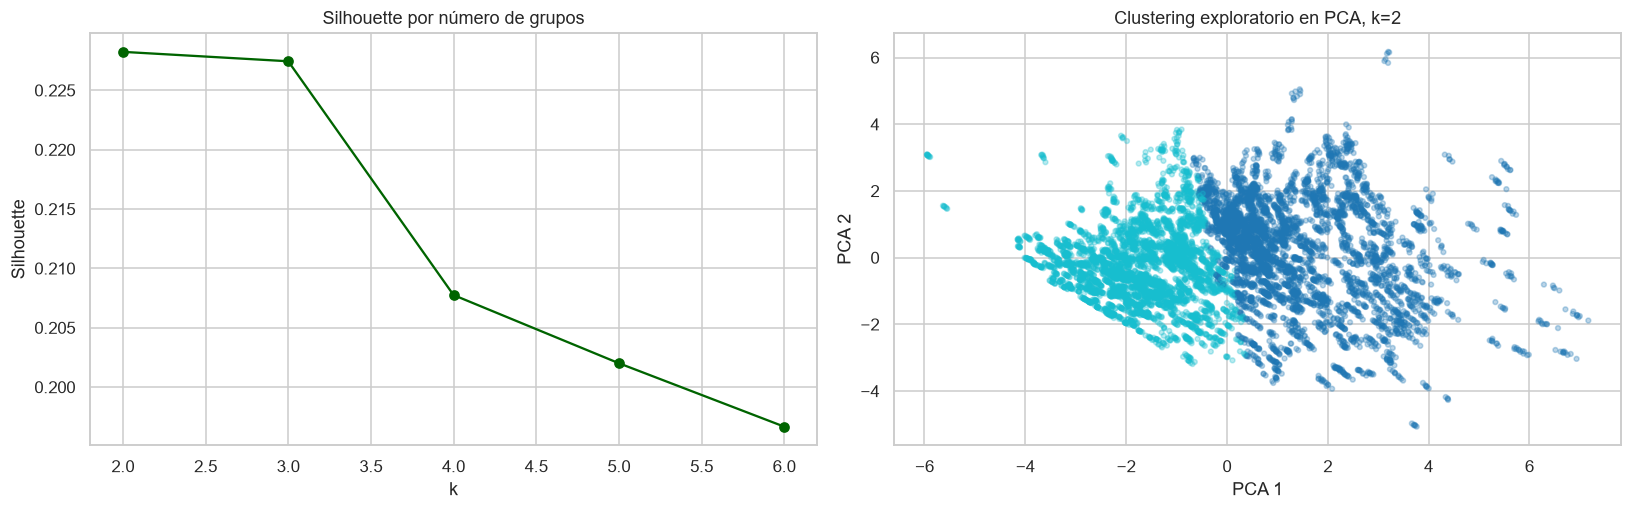

Interpretación:
- El mejor silhouette entre k=2,...,6 es 0.2282 con k=2.
- Un silhouette cercano a cero o bajo indica solapamiento; incluso un valor mayor debe validarse por periodo, programa y disponibilidad antes de interpretar subpoblaciones.
- La estructura de grupos se conserva como evidencia exploratoria y no como variable derivada para la regresión.


In [16]:
cluster_n = min(10000, len(X_pca))
cluster_rng = np.random.default_rng(RANDOM_STATE)
cluster_idx = cluster_rng.choice(len(X_pca), cluster_n, replace=False) if len(X_pca) > cluster_n else np.arange(len(X_pca))
cluster_components = X_pca[cluster_idx, :min(10, X_pca.shape[1])]

cluster_results = []
cluster_models = {}
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(cluster_components)
    score = silhouette_score(cluster_components, labels, sample_size=min(5000, len(cluster_components)), random_state=RANDOM_STATE)
    cluster_results.append({'k': k, 'silhouette': score, 'tamano_minimo': np.bincount(labels).min(), 'tamano_maximo': np.bincount(labels).max()})
    cluster_models[k] = (model, labels)

cluster_profile = pd.DataFrame(cluster_results)
display(cluster_profile.round(5))
best_k = int(cluster_profile.loc[cluster_profile['silhouette'].idxmax(), 'k'])
best_model, best_labels = cluster_models[best_k]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(cluster_profile['k'], cluster_profile['silhouette'], marker='o', color='darkgreen')
axes[0].set_title('Silhouette por número de grupos')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette')
axes[1].scatter(cluster_components[:, 0], cluster_components[:, 1], c=best_labels, s=10, alpha=0.3, cmap='tab10')
axes[1].set_title(f'Clustering exploratorio en PCA, k={best_k}')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'- El mejor silhouette entre k=2,...,6 es {cluster_profile.loc[cluster_profile["k"] == best_k, "silhouette"].iloc[0]:.4f} con k={best_k}.')
print('- Un silhouette cercano a cero o bajo indica solapamiento; incluso un valor mayor debe validarse por periodo, programa y disponibilidad antes de interpretar subpoblaciones.')
print('- La estructura de grupos se conserva como evidencia exploratoria y no como variable derivada para la regresión.')

## 15. Auditoría de fuga de datos: disponibilidad y proxies

La disponibilidad se evalúa desde el momento hipotético de predicción. La única variable excluida por temporalidad es nota_final. Las demás predictoras se consideran disponibles antes del primer parcial, de acuerdo con la regla de negocio definida para este ejercicio.
La tabla es una hipótesis operativa que debe contrastarse con el proceso institucional de captura;
una asociación alta no convierte por sí sola a una variable en fuga, y una asociación baja no
garantiza disponibilidad válida.

In [17]:
def availability_assessment(column):
    if column == TARGET:
        return 'objetivo', 'La variable que se desea predecir no puede estar entre las entradas.'
    if column in EXCLUDED_FROM_MODEL or 'nota_final' in str(column).lower():
        return 'descartar', 'Resultado posterior y posible proxy directo del desempeño; no debe utilizarse como entrada.'
    return 'disponible antes del primer parcial', 'La regla de negocio establece que esta predictora estaba disponible antes del primer parcial; se conserva para el modelado.'

availability_rows = []
for column in [*feature_cols, TARGET, *EXCLUDED_FROM_MODEL]:
    status, justification = availability_assessment(column)
    availability_rows.append({'variable': column, 'estado_fuga': status, 'justificacion': justification})
availability_audit = pd.DataFrame(availability_rows).set_index('variable')
display(availability_audit)

print('Interpretación:')
print(f'- Variables para descartar de inmediato: {availability_audit.index[availability_audit.estado_fuga == "descartar"].tolist()}.')
print('- Todas las predictoras, excepto nota_final, se consideran disponibles antes del primer parcial según la regla de negocio.')
print('- La disponibilidad debe resolverse antes de seleccionar variables o reportar desempeño como predicción temprana.')

,estado_fuga,justificacion
variable,,
Icfes_nuevo,disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Icfes_Matematicas,disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Tiempo_empleado_en_la_verificación_de_conocimientos,disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Dominio_Inicial,disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Categoria_temas_inicial,disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
avance_precalculo_aleks,disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Dominio_Final,disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Categoria_temas_final,disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Tiempo_Total_Tiempo,disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...


Interpretación:
- Variables para descartar de inmediato: ['nota_final'].
- Todas las predictoras, excepto nota_final, se consideran disponibles antes del primer parcial según la regla de negocio.
- La disponibilidad debe resolverse antes de seleccionar variables o reportar desempeño como predicción temprana.


### 15.1 Rendimiento univariado como señal de alerta

En regresión, AUC no es la métrica natural. Se calcula en su lugar el R² fuera de muestra de
un modelo univariado por variable, además de la asociación monotónica o la información mutua.
Un valor muy alto puede revelar una variable derivada del objetivo, un proxy o una codificación
posterior; no demuestra causalidad y siempre se interpreta junto con la auditoría semántica.

In [18]:
audit_predictor_cols = [column for column in df.columns if column != TARGET]
cv_univariate = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
univariate_rows = []

for column in audit_predictor_cols:
    x_one = df[[column]]
    if column in df.select_dtypes(include=np.number).columns:
        estimator = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('model', ExtraTreesRegressor(n_estimators=60, max_depth=7, min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=-1)),
        ])
        scores = cross_val_score(estimator, x_one, y, cv=cv_univariate, scoring='r2', n_jobs=1)
        association = stats.spearmanr(x_one[column], y, nan_policy='omit').statistic
        mutual_info = safe_mi_numeric(x_one[column], y)
    else:
        estimator = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_dense_ohe()),
            ('model', Ridge(alpha=1.0)),
        ])
        scores = cross_val_score(estimator, x_one, y, cv=cv_univariate, scoring='r2', n_jobs=1)
        association = np.nan
        mutual_info = safe_mi_categorical(x_one[column], y)
    semantic_status, _ = availability_assessment(column)
    alert = bool(
        semantic_status == 'descartar'
        or np.nanmean(scores) >= LEAKAGE_R2_ALERT
        or (np.isfinite(association) and abs(association) >= 0.90)
    )
    univariate_rows.append({
        'variable': column,
        'tipo': 'numérica' if column in df.select_dtypes(include=np.number).columns else 'categórica',
        'r2_oof_media': np.mean(scores), 'r2_oof_std': np.std(scores),
        'spearman': association, 'mutual_info': mutual_info,
        'estado_semantico': semantic_status, 'alerta': alert,
    })

univariate_audit = pd.DataFrame(univariate_rows).set_index('variable').sort_values('r2_oof_media', ascending=False)
display(univariate_audit.round(5))

print('Interpretación:')
print(f'- Umbral de alerta exploratorio para R² univariado: {LEAKAGE_R2_ALERT:.2f}.')
print(f'- Variables marcadas por rendimiento o semántica: {univariate_audit.index[univariate_audit.alerta].tolist()}.')
print('- En un problema de regresión, el R² univariado fuera de muestra es preferible a AUC; la alerta debe confirmarse con el momento real de disponibilidad y con el origen de la variable.')

,tipo,r2_oof_media,r2_oof_std,spearman,mutual_info,estado_semantico,alerta
variable,,,,,,,
nota_final,numérica,0.69502,0.00244,0.83459,0.66323,descartar,True
Icfes_nuevo,numérica,0.28773,0.00309,0.52747,0.33954,disponible antes del primer parcial,False
Dominio_Final,numérica,0.25984,0.00428,0.46194,0.59176,disponible antes del primer parcial,False
Categoria_temas_inicial,categórica,0.22947,0.00340,NaN,0.16345,disponible antes del primer parcial,False
Dominio_Inicial,numérica,0.22160,0.00337,0.46170,0.21885,disponible antes del primer parcial,False
Categoria_temas_final,categórica,0.21240,0.00444,NaN,0.17947,disponible antes del primer parcial,False
Icfes_Matematicas,numérica,0.18370,0.00214,0.41129,0.23635,disponible antes del primer parcial,False
Tiempo_total_Aprendidos_hora,numérica,0.15531,0.00342,0.36583,0.21130,disponible antes del primer parcial,False
cumplimiento_temas,categórica,0.14285,0.00607,NaN,0.08477,disponible antes del primer parcial,False


Interpretación:
- Umbral de alerta exploratorio para R² univariado: 0.80.
- Variables marcadas por rendimiento o semántica: ['nota_final'].
- En un problema de regresión, el R² univariado fuera de muestra es preferible a AUC; la alerta debe confirmarse con el momento real de disponibilidad y con el origen de la variable.


### 15.2 Duplicados, entidades repetidas y consistencia entre particiones

La comparación de huellas descarta duplicados completos entre archivos. Cuando no existe un
identificador de estudiante, no es posible verificar de manera concluyente que dos filas
parcialmente distintas no pertenezcan a la misma persona. Esta limitación es especialmente
relevante en una base aumentada y debe resolverse conservando una clave de entidad en futuras
exportaciones o certificando el proceso de separación previo.

In [19]:
print('Auditoría de duplicados y entidades:')
print(f'- Duplicados completos dentro de train: {int(df_train_raw.duplicated().sum())}.')
print(f'- Duplicados completos dentro de test: {int(df_test_raw.duplicated().sum())}.')
print(f'- Filas completas compartidas entre train y test: {len(train_hash_set.intersection(test_hash_set))}.')
if identifier_candidates:
    for candidate in identifier_candidates:
        column = candidate['variable']
        train_values = set(value_label(df_train_raw[column]))
        test_values = set(value_label(df_test_raw[column]))
        print(f'- {column}: valores compartidos entre particiones = {len(train_values.intersection(test_values))}.')
else:
    print('- No hay clave de entidad disponible para comprobar estudiantes repetidos con valores parcialmente distintos.')
print('- La documentación del proceso de preparación indica separación por estudiante antes de aumentar; este notebook verifica la integridad observable, pero no puede reconstruir esa garantía sin el identificador.')

Auditoría de duplicados y entidades:
- Duplicados completos dentro de train: 0.
- Duplicados completos dentro de test: 0.
- Filas completas compartidas entre train y test: 0.
- programa_en_matricula: valores compartidos entre particiones = 16.
- division_en_matricula: valores compartidos entre particiones = 6.
- La documentación del proceso de preparación indica separación por estudiante antes de aumentar; este notebook verifica la integridad observable, pero no puede reconstruir esa garantía sin el identificador.


## 16. Síntesis de decisiones de fuga y recomendaciones para modelado

La siguiente tabla separa las variables que se descartan de las que pueden pasar al modelado. La exclusión de nota_final es definitiva; las demás predictoras se consideran temporalmente disponibles antes del primer parcial.

In [20]:
decision_rows = []
for column in feature_cols:
    status, justification = availability_assessment(column)
    if status == 'descartar':
        decision = 'DESCARTAR'
    else:
        decision = 'CANDIDATA; disponible antes del primer parcial'
    if column in univariate_audit.index and bool(univariate_audit.loc[column, 'alerta']):
        justification += ' El rendimiento univariado o la semántica activó una señal de alerta.'
    decision_rows.append({'variable': column, 'decision': decision, 'justificacion': justification})

decision_rows.extend([
    {'variable': TARGET, 'decision': 'OBJETIVO', 'justificacion': 'Se utiliza como variable respuesta y nunca como predictor.'},
    {'variable': EXCLUDED_FROM_MODEL[0], 'decision': 'DESCARTAR', 'justificacion': 'Resultado posterior/proxy del desempeño; se conserva únicamente para auditar fuga.'},
])
leakage_decisions = pd.DataFrame(decision_rows).set_index('variable')
display(leakage_decisions)

print('Conclusiones de la auditoría:')
print(f'- Descartar: {leakage_decisions.index[leakage_decisions.decision == "DESCARTAR"].tolist()}.')
print('- No quedan predictoras en observación temporal; nota_final se mantiene descartada.')
print('- Antes del modelado se debe confirmar que toda variable candidata estaba disponible antes del momento exacto de predicción.')
print('- No se ejecuta imputación definitiva, transformación definitiva ni selección final en este notebook. Los outliers no se eliminan porque representan comportamiento real de la población.')

,decision,justificacion
variable,,
Icfes_nuevo,CANDIDATA; disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Icfes_Matematicas,CANDIDATA; disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Tiempo_empleado_en_la_verificación_de_conocimientos,CANDIDATA; disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Dominio_Inicial,CANDIDATA; disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Categoria_temas_inicial,CANDIDATA; disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
avance_precalculo_aleks,CANDIDATA; disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Dominio_Final,CANDIDATA; disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Categoria_temas_final,CANDIDATA; disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...
Tiempo_Total_Tiempo,CANDIDATA; disponible antes del primer parcial,La regla de negocio establece que esta predictora estaba disponible antes del primer p...


Conclusiones de la auditoría:
- Descartar: ['nota_final'].
- No quedan predictoras en observación temporal; nota_final se mantiene descartada.
- Antes del modelado se debe confirmar que toda variable candidata estaba disponible antes del momento exacto de predicción.
- No se ejecuta imputación definitiva, transformación definitiva ni selección final en este notebook. Los outliers no se eliminan porque representan comportamiento real de la población.


## 17. Conclusiones del EDA, tratamientos y recomendaciones

### Conclusión general

La base queda preparada para un notebook independiente de regresión. El conjunto de prueba se
leyó únicamente para verificar esquema e integridad; las decisiones exploratorias se calcularon
con train. La división contiene 24.000 filas de entrenamiento y 6.000 de prueba, y no se vuelve a
ejecutar una partición aleatoria.

Antes del EDA se aplicaron las reglas de negocio del dominio y del tiempo de aprendizaje. Se
detectaron 58 registros extraños: ninguno incumplió la relación Dominio_Final >= Dominio_Inicial,
ninguno incumplió la regla de Tiempo_Total_Tiempo igual a cero y 58 incumplieron la regla de
Tiempo_total_Aprendidos_hora igual a cero. Esos registros se excluyeron sin imputación, dejando
23.942 filas válidas para el análisis. Los CSV originales permanecen intactos.

### Variable objetivo

La variable nota_primer_parcial está acotada entre 0,5 y 5,0. Antes de aplicar las reglas de
negocio presentó media aproximada de 3,532, mediana de 3,720, asimetría de -0,444 y curtosis de
exceso de -0,864. La distribución no muestra colas pesadas que justifiquen una transformación
obligatoria.

Decisión para el modelado:

- Mantener el objetivo en su escala original.
- No aplicar logaritmo ni Box-Cox como transformación principal.
- No recortar, winsorizar ni eliminar valores extremos del objetivo.
- Reportar MAE y RMSE en unidades de calificación para conservar la interpretación académica.
- Si el diagnóstico de residuos del modelo posterior muestra heterocedasticidad o errores
  sistemáticos, evaluar una transformación únicamente como análisis de sensibilidad y ajustarla
  usando train.

### Tratamiento de variables numéricas

- Los faltantes de Tiempo_empleado_en_la_verificación_de_conocimientos, Tiempo_Total_Tiempo y
  Tiempo_total_Aprendidos_hora deben imputarse dentro del pipeline, preferiblemente con mediana
  calculada solo en train. Puede añadirse un indicador de ausencia si la falta de medición tiene
  significado académico.
- Las inconsistencias de las reglas de negocio no deben imputarse: ya fueron clasificadas como
  registros extraños y excluidas.
- Las variables de dominio, avance y tiempo se conservan porque son coherentes con la temporalidad
  definida: estaban disponibles antes del primer parcial.
- Para modelos lineales o SVR se recomienda imputación por mediana y escalado. StandardScaler es
  una primera opción; RobustScaler puede compararse como sensibilidad sin eliminar observaciones.
- Para modelos basados en árboles el escalado no es indispensable, pero la imputación debe seguir
  siendo parte de un flujo reproducible.
- Las distribuciones asimétricas no obligan a transformar las predictoras. Una transformación
  log1p solo debe probarse para variables no negativas si el modelo posterior muestra beneficio
  estable en validación cruzada.

### Tratamiento de variables categóricas

- Las variables categóricas tienen cardinalidades manejables para codificación one-hot.
- Las categorías raras deben revisarse por posible error de rotulación antes de agruparlas. Si se
  agrupan, el umbral y el mapa deben aprenderse únicamente con train.
- Los faltantes categóricos pueden imputarse con la moda o tratarse como una categoría explícita,
  según si la ausencia tiene significado operacional.
- OneHotEncoder con manejo de categorías desconocidas es adecuado para la primera versión del
  pipeline.
- No se recomienda eliminar automáticamente categorías poco frecuentes si representan programas,
  asignaturas o subpoblaciones institucionales reales.

### Outliers y calidad de los datos

Los outliers univariados y multivariados se identificaron mediante IQR, distancia de Mahalanobis e
Isolation Forest. En este ejercicio no se eliminan, porque representan comportamiento real de la
población. Las detecciones sirven para documentar casos extremos y revisar su estabilidad, no para
forzar una distribución artificialmente limpia.

La única exclusión automática corresponde a registros que incumplen reglas de negocio explícitas.
Un outlier que cumple esas reglas debe conservarse en train y test, y su influencia puede
evaluarse mediante métricas robustas o análisis de sensibilidad.

### Relaciones, redundancia y dimensionalidad

- Pearson y Spearman permiten distinguir relaciones lineales y monotónicas; la información mutua
  ayuda a identificar dependencias no lineales.
- Las diferencias entre grupos se acompañan de tamaños de efecto y corrección FDR, porque el
  tamaño muestral hace que muchos valores p sean pequeños sin implicar relevancia práctica.
- Los pares con correlación alta y los VIF deben revisarse antes de un modelo lineal. La decisión
  puede resolverse mediante regularización, selección por redundancia o comparación de variables,
  siempre apoyada en disponibilidad y sentido académico, no solo en p-valores.
- PCA muestra la dimensionalidad efectiva después de codificar las categorías. Su uso es
  exploratorio; no se convierte automáticamente en una transformación del modelo final.
- El clustering y la detección multivariada de outliers son herramientas descriptivas y no generan
  variables predictoras adicionales en esta etapa.

### Auditoría de fuga y particiones

- nota_final queda descartada de manera definitiva por ser un resultado posterior y un proxy directo
  del desempeño.
- Todas las demás predictoras se consideran disponibles antes del primer parcial según la regla de
  negocio establecida para este proyecto.
- No se detectaron duplicados completos dentro de train o test ni filas completas compartidas
  entre las particiones.
- El esquema estandarizado no contiene un identificador persistente de estudiante; por tanto, no
  puede demostrarse con el CSV que no existan entidades repetidas en filas parcialmente distintas.
  La documentación de preparación indica que la separación se hizo por estudiante antes de la
  aumentación.
- El rendimiento univariado se interpreta como señal de alerta de fuga, no como evidencia causal ni
  como selección definitiva de variables.

### Tratamientos recomendados para el notebook de regresión

| Elemento | Decisión recomendada |
| --- | --- |
| Partición | Usar los CSV train/test existentes; no volver a mezclar ni particionar. |
| Registros extraños | Excluir los que incumplan las reglas de negocio y reportar el conteo. |
| Outliers válidos | Conservarlos; no aplicar eliminación ni winsorización. |
| Objetivo | Mantener nota_primer_parcial sin transformación principal. |
| Numéricas | Imputación por mediana dentro del pipeline; escalar para modelos sensibles a escala. |
| Categóricas | Imputación documentada y one-hot con categorías desconocidas ignoradas. |
| nota_final | Excluir completamente de X y conservar solo para auditoría. |
| Selección | Cruzar asociación, redundancia, disponibilidad y estabilidad; no seleccionar solo por p-valor. |
| Evaluación | Validación cruzada sobre train y evaluación final una sola vez en test. |

El siguiente notebook debe concentrarse exclusivamente en la regresión y reutilizar estas decisiones
sin recalcularlas utilizando información del conjunto de prueba.